This notebook performs **feature extraction and selection** on the processed signal dataset to build a compact, informative, and homogeneous feature set for monthly return prediction.

The workflow stacks all assets into a single pooled dataset, removes warm-up rows, resamples to month-end frequency, defines the next-month return target, and applies iterative filtering using domain knowledge, correlation analysis, VIF, and mutual information.

In [16]:
# imports
import os
import sys
sys.path.append(os.path.abspath(".."))
from src.utils.data_loader import DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from pandas.plotting import scatter_matrix
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.feature_selection import mutual_info_regression
from numpy.lib.stride_tricks import sliding_window_view
from scipy.stats import linregress




In [3]:
# can't perform feature analysis and selection on 1 stock and assume the same for others, but we do want to keep the same features for all data sets
# this way our dataset is homogeneous
# all 30 stocks will be used, stacked on each other,
# this helps remove time dependency and will also help statistical testing as there are more observations
# making it more robust

dl = DataLoader()
dfs = dl.load_multiple_data("processed")


MS.csv loaded succesfully
MMM.csv loaded succesfully
GS.csv loaded succesfully
CAT.csv loaded succesfully
AVGO.csv loaded succesfully
BA.csv loaded succesfully
MCD.csv loaded succesfully
HD.csv loaded succesfully
UNH.csv loaded succesfully
AMZN.csv loaded succesfully
META.csv loaded succesfully
AAPL.csv loaded succesfully
SLB.csv loaded succesfully
JPM.csv loaded succesfully
VZ.csv loaded succesfully
GOOG.csv loaded succesfully
CVX.csv loaded succesfully
NEE.csv loaded succesfully
BAC.csv loaded succesfully
UPS.csv loaded succesfully
MSFT.csv loaded succesfully
LIN.csv loaded succesfully
CMCSA.csv loaded succesfully
XOM.csv loaded succesfully
NKE.csv loaded succesfully
NVDA.csv loaded succesfully
JNJ.csv loaded succesfully
ABBV.csv loaded succesfully
PFE.csv loaded succesfully
DOW.csv loaded succesfully


In [153]:
len(dfs["AAPL"].columns)

46

46 features is far too many, most likely many of them are redundant
or highly correlated, will procede to explore, investigate and extract subset of "golden" features

In [154]:
dfs["AAPL"]

,Close,High,Low,Open,Volume,Returns,Log Returns,Monthly Log Returns,Quarterly Log Returns,Semi-annual Log Returns,...,Average Losses,RS,RSI,14-day Average True Range,Normalized Average True Range,10-day Efficiency Ratio,21-day Efficiency Ratio,Body Up,Body Down,Monthly Conviction Ratio
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-04,6.412383,6.427064,6.363543,6.395004,493729600,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.017379,-0.000000,NaN
2010-01-05,6.423470,6.459726,6.389612,6.430063,601904800,0.001729,0.001728,NaN,NaN,NaN,...,0.000000,inf,100.000000,0.070114,1.091526,NaN,NaN,0.000000,0.006592,NaN
2010-01-06,6.321295,6.448937,6.314703,6.423469,552160000,-0.015907,-0.016034,NaN,NaN,NaN,...,0.007298,0.100767,9.154223,0.074694,1.181623,NaN,NaN,0.000000,0.102174,NaN
2010-01-07,6.309610,6.352158,6.263767,6.344667,477131200,-0.001848,-0.001850,NaN,NaN,NaN,...,0.007612,0.089717,8.233076,0.075672,1.199318,NaN,NaN,0.000000,0.035057,NaN
2010-01-08,6.351560,6.352160,6.264069,6.301222,447610800,0.006649,0.006627,NaN,NaN,NaN,...,0.007068,0.513668,33.935307,0.076559,1.205363,NaN,NaN,0.050338,-0.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-26,255.171234,256.320153,249.566478,251.244900,55969200,0.029713,0.029280,-0.064255,-0.015226,0.179558,...,1.352045,0.675863,40.329259,5.127246,2.009335,0.156152,0.397607,3.926334,-0.000000,0.508941
2026-01-27,258.028534,261.705117,257.968592,258.927717,49648300,0.011198,0.011135,-0.058429,-0.016495,0.189899,...,1.255471,0.838426,45.605644,5.227720,2.026024,0.072423,0.352862,0.000000,0.899183,0.439436
2026-01-28,256.200287,258.618008,254.272083,257.409147,41288000,-0.007085,-0.007111,-0.064041,-0.046141,0.195861,...,1.296383,0.753969,42.986434,5.164734,2.015897,0.162495,0.373075,0.000000,1.208860,0.432422


In [155]:
# first thing to do is drop the "warm up" period
# the first 126 rows have NaNs as some features/indicators have a warm up period

dfs["AAPL"].isna().sum()

Close                                          0
High                                           0
Low                                            0
Open                                           0
Volume                                         0
Returns                                        1
Log Returns                                    1
Monthly Log Returns                           21
Quarterly Log Returns                         63
Semi-annual Log Returns                      126
Daily Volatility                               0
Monthly Volatility                            21
Quarterly Volatility                          63
Semi-annual Volatility                       126
Volatility Ratio                              63
MA20                                          19
MA60                                          59
MA20/MA60                                     59
Distance from MA20                            19
Distance from MA60                            59
VMA20               

In [156]:
for df in dfs.values():
    df.dropna(how='any', inplace=True)
dfs["AAPL"].isna().sum()

Close                                        0
High                                         0
Low                                          0
Open                                         0
Volume                                       0
Returns                                      0
Log Returns                                  0
Monthly Log Returns                          0
Quarterly Log Returns                        0
Semi-annual Log Returns                      0
Daily Volatility                             0
Monthly Volatility                           0
Quarterly Volatility                         0
Semi-annual Volatility                       0
Volatility Ratio                             0
MA20                                         0
MA60                                         0
MA20/MA60                                    0
Distance from MA20                           0
Distance from MA60                           0
VMA20                                        0
VMA60        

In [157]:
# next thing to do is turn "daily" data set into monthly, as the models are predicting returns of next month
# data needs to be "summarized" into one row for each month
for k,v in dfs.items():
    dfs[k] = v.resample("BME").last()
dfs["AAPL"]

,Close,High,Low,Open,Volume,Returns,Log Returns,Monthly Log Returns,Quarterly Log Returns,Semi-annual Log Returns,...,Average Losses,RS,RSI,14-day Average True Range,Normalized Average True Range,10-day Efficiency Ratio,21-day Efficiency Ratio,Body Up,Body Down,Monthly Conviction Ratio
Date,,,,,,,,,,,,,,,,,,,,,
2010-07-30,7.707984,7.781394,7.637571,7.667235,448210000,-0.003332,-0.003337,0.022486,-0.014817,0.292241,...,0.046735,1.013573,50.337050,0.217560,2.822522,0.237321,0.093802,0.040749,-0.000000,0.760085
2010-08-31,7.284005,7.327751,7.201607,7.246551,420786800,0.002474,0.002471,-0.074299,-0.082287,0.149561,...,0.045734,0.659795,39.751605,0.170780,2.344584,0.391961,0.375377,0.037454,-0.000000,0.693497
2010-09-30,8.502005,8.689273,8.427097,8.659310,673391600,-0.012597,-0.012677,0.154621,0.132731,0.184389,...,0.029218,1.856819,64.996031,0.182829,2.150427,0.258830,0.643908,0.000000,0.157306,2.221775
2010-10-29,9.018264,9.165083,9.014967,9.115644,430511200,-0.013957,-0.014055,0.058950,0.139272,0.122232,...,0.039298,1.212264,54.797429,0.184925,2.050565,0.548213,0.259839,0.000000,0.097380,1.552620
2010-11-30,9.322989,9.419170,9.314599,9.394600,501858000,-0.018051,-0.018216,0.033231,0.246802,0.164515,...,0.050566,1.119397,52.816779,0.184640,1.980484,0.099538,0.132613,0.000000,0.071611,1.116932
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-30,254.145599,255.433139,252.628487,254.375158,37704300,0.000786,0.000786,0.092471,0.204274,0.138994,...,0.896451,2.140581,68.158757,4.717149,1.856081,0.529564,0.330979,0.000000,0.229558,1.724094
2025-10-31,269.855652,276.792443,268.647962,276.463053,86167100,-0.003795,-0.003802,0.050210,0.285997,0.277520,...,0.799845,2.232777,69.066843,5.218651,1.933868,0.628216,0.234836,0.000000,6.607401,0.798373
2025-11-28,278.589325,278.739179,275.731983,277.000815,20135600,0.004684,0.004673,0.034333,0.184302,0.330219,...,0.665550,2.165319,68.407607,5.437101,1.951655,0.273909,0.249744,1.588510,-0.000000,1.416251


In [ ]:
# next create "target" variable, which is the log returns of the next month
for k,v in dfs.items():
    v["Target"] = v["Log Returns"].shift(-1)
dfs["AAPL"]

,Close,High,Low,Open,Volume,Returns,Log Returns,Monthly Log Returns,Quarterly Log Returns,Semi-annual Log Returns,...,RS,RSI,14-day Average True Range,Normalized Average True Range,10-day Efficiency Ratio,21-day Efficiency Ratio,Body Up,Body Down,Monthly Conviction Ratio,Target
Date,,,,,,,,,,,,,,,,,,,,,
2010-07-30,7.707984,7.781394,7.637571,7.667235,448210000,-0.003332,-0.003337,0.022486,-0.014817,0.292241,...,1.013573,50.337050,0.217560,2.822522,0.237321,0.093802,0.040749,-0.000000,0.760085,0.002471
2010-08-31,7.284005,7.327751,7.201607,7.246551,420786800,0.002474,0.002471,-0.074299,-0.082287,0.149561,...,0.659795,39.751605,0.170780,2.344584,0.391961,0.375377,0.037454,-0.000000,0.693497,-0.012677
2010-09-30,8.502005,8.689273,8.427097,8.659310,673391600,-0.012597,-0.012677,0.154621,0.132731,0.184389,...,1.856819,64.996031,0.182829,2.150427,0.258830,0.643908,0.000000,0.157306,2.221775,-0.014055
2010-10-29,9.018264,9.165083,9.014967,9.115644,430511200,-0.013957,-0.014055,0.058950,0.139272,0.122232,...,1.212264,54.797429,0.184925,2.050565,0.548213,0.259839,0.000000,0.097380,1.552620,-0.018216
2010-11-30,9.322989,9.419170,9.314599,9.394600,501858000,-0.018051,-0.018216,0.033231,0.246802,0.164515,...,1.119397,52.816779,0.184640,1.980484,0.099538,0.132613,0.000000,0.071611,1.116932,-0.003404
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-30,254.145599,255.433139,252.628487,254.375158,37704300,0.000786,0.000786,0.092471,0.204274,0.138994,...,2.140581,68.158757,4.717149,1.856081,0.529564,0.330979,0.000000,0.229558,1.724094,-0.003802
2025-10-31,269.855652,276.792443,268.647962,276.463053,86167100,-0.003795,-0.003802,0.050210,0.285997,0.277520,...,2.232777,69.066843,5.218651,1.933868,0.628216,0.234836,0.000000,6.607401,0.798373,0.004673
2025-11-28,278.589325,278.739179,275.731983,277.000815,20135600,0.004684,0.004673,0.034333,0.184302,0.330219,...,2.165319,68.407607,5.437101,1.951655,0.273909,0.249744,1.588510,-0.000000,1.416251,-0.004478


In [ ]:
# drop the last row as it has a NaN now (no next month)
for df in dfs.values():
    df.dropna(subset=["Target"], inplace=True)
dfs["AAPL"]

,Close,High,Low,Open,Volume,Returns,Log Returns,Monthly Log Returns,Quarterly Log Returns,Semi-annual Log Returns,...,RS,RSI,14-day Average True Range,Normalized Average True Range,10-day Efficiency Ratio,21-day Efficiency Ratio,Body Up,Body Down,Monthly Conviction Ratio,Target
Date,,,,,,,,,,,,,,,,,,,,,
2010-07-30,7.707984,7.781394,7.637571,7.667235,448210000,-0.003332,-0.003337,0.022486,-0.014817,0.292241,...,1.013573,50.337050,0.217560,2.822522,0.237321,0.093802,0.040749,-0.000000,0.760085,0.002471
2010-08-31,7.284005,7.327751,7.201607,7.246551,420786800,0.002474,0.002471,-0.074299,-0.082287,0.149561,...,0.659795,39.751605,0.170780,2.344584,0.391961,0.375377,0.037454,-0.000000,0.693497,-0.012677
2010-09-30,8.502005,8.689273,8.427097,8.659310,673391600,-0.012597,-0.012677,0.154621,0.132731,0.184389,...,1.856819,64.996031,0.182829,2.150427,0.258830,0.643908,0.000000,0.157306,2.221775,-0.014055
2010-10-29,9.018264,9.165083,9.014967,9.115644,430511200,-0.013957,-0.014055,0.058950,0.139272,0.122232,...,1.212264,54.797429,0.184925,2.050565,0.548213,0.259839,0.000000,0.097380,1.552620,-0.018216
2010-11-30,9.322989,9.419170,9.314599,9.394600,501858000,-0.018051,-0.018216,0.033231,0.246802,0.164515,...,1.119397,52.816779,0.184640,1.980484,0.099538,0.132613,0.000000,0.071611,1.116932,-0.003404
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-29,231.698380,232.936026,230.929840,232.067671,39418400,-0.001806,-0.001808,0.113006,0.145916,-0.038491,...,1.937835,65.961325,4.261940,1.839434,0.034440,0.422199,0.000000,0.369291,1.353943,0.000786
2025-09-30,254.145599,255.433139,252.628487,254.375158,37704300,0.000786,0.000786,0.092471,0.204274,0.138994,...,2.140581,68.158757,4.717149,1.856081,0.529564,0.330979,0.000000,0.229558,1.724094,-0.003802
2025-10-31,269.855652,276.792443,268.647962,276.463053,86167100,-0.003795,-0.003802,0.050210,0.285997,0.277520,...,2.232777,69.066843,5.218651,1.933868,0.628216,0.234836,0.000000,6.607401,0.798373,0.004673


In [ ]:
# stack all datasets now for a cross sectional analysis
# this way we can see if correlations and redundancies are consistent across all stocks
# also helps lose time dependence as we only care about relationship between features
df = pd.concat(dfs.values(),axis=0).reset_index(drop=True)
df

,Close,High,Low,Open,Volume,Returns,Log Returns,Monthly Log Returns,Quarterly Log Returns,Semi-annual Log Returns,...,RS,RSI,14-day Average True Range,Normalized Average True Range,10-day Efficiency Ratio,21-day Efficiency Ratio,Body Up,Body Down,Monthly Conviction Ratio,Target
0,19.087612,19.313919,18.818873,18.896665,16038300,0.000000,0.000000,0.152737,-0.111184,0.011336,...,1.732103,63.398164,0.598177,3.133848,0.974548,0.557497,0.190947,-0.000000,1.573199,0.010587
1,17.461033,17.545897,17.142788,17.248869,13682700,0.010643,0.010587,-0.114312,-0.094229,-0.133644,...,0.595438,37.321298,0.458968,2.628527,0.511865,0.483036,0.212164,-0.000000,0.681006,0.008137
2,17.453959,17.821708,17.369093,17.461031,21464700,0.008170,0.008137,-0.000405,0.068447,-0.164650,...,0.674913,40.295403,0.476924,2.732468,0.517241,0.000989,0.000000,0.007072,0.671463,0.000402
3,17.624763,17.801932,17.553896,17.653110,18086200,0.000403,0.000402,0.009738,-0.104979,-0.197844,...,0.903942,47.477383,0.474413,2.691742,0.042420,0.038572,0.000000,0.028346,1.015751,-0.018632
4,17.334200,17.553890,17.270420,17.397981,11776300,-0.018459,-0.018632,-0.016624,-0.007290,-0.101520,...,0.721657,41.916430,0.473155,2.729605,0.383084,0.042933,0.000000,0.063781,1.180685,-0.004401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5401,23.985369,24.238564,23.605577,23.654269,8791800,0.016928,0.016786,0.070288,-0.104563,-0.397550,...,1.173242,53.985796,0.900604,3.754807,0.436381,0.156221,0.331100,-0.000000,1.060995,0.001746
5402,22.329863,22.355181,21.729011,22.183789,14368700,0.001748,0.001746,-0.071519,-0.179321,-0.381652,...,0.768237,43.446508,0.851715,3.814244,0.406824,0.200000,0.146074,-0.000000,0.670766,0.002099
5403,23.225784,23.459503,22.982327,23.293952,13052700,0.002101,0.002099,0.006731,0.113902,-0.204354,...,1.133033,53.118411,0.909213,3.914670,0.304348,0.013559,0.000000,0.068168,0.625227,0.012234
5404,23.570820,23.738830,23.313863,23.452224,7253900,0.012309,0.012234,-0.026729,-0.017435,-0.121997,...,1.520317,60.322448,0.825024,3.500191,0.189513,0.063021,0.118596,-0.000000,0.824372,-0.005545


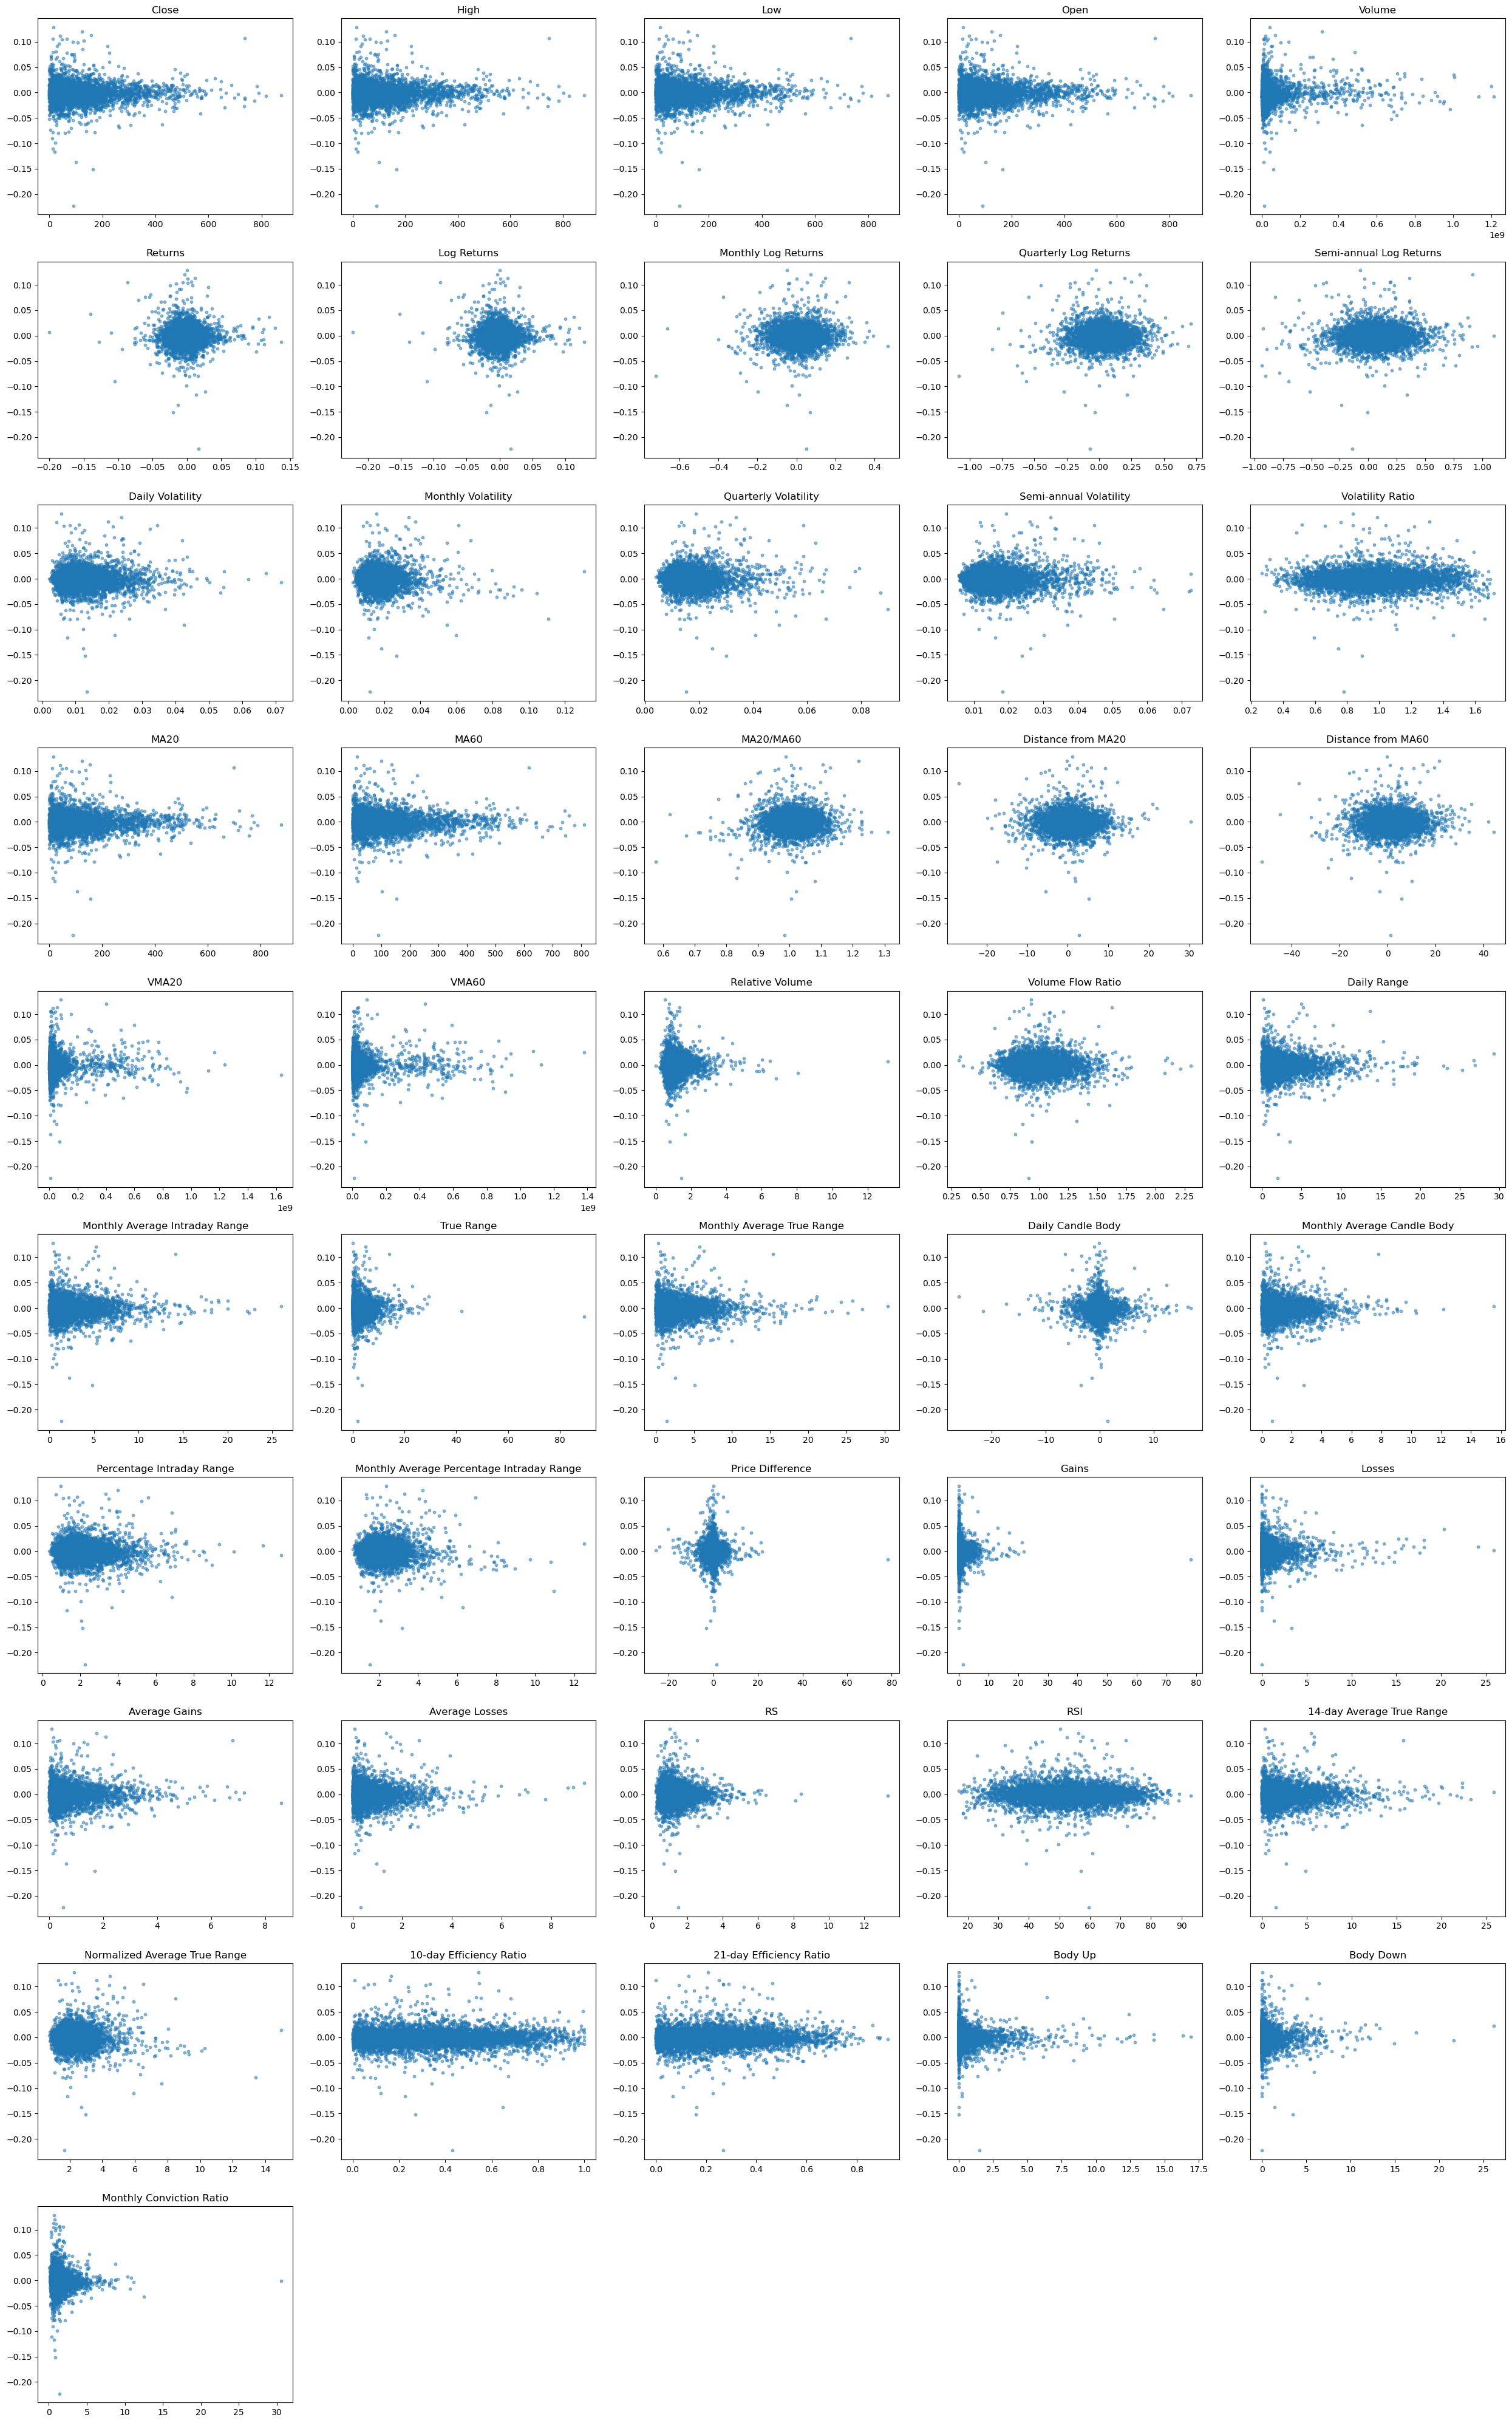

In [91]:
# quick visualization of plots of features to target

cols = [c for c in df.columns if c != "Target"]
n_cols = 5
n_rows = math.ceil(len(cols)/n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].scatter(df[col], df["Target"], alpha=0.5, s=10)
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [92]:
# as expected, bascially no linear relationship between features and target
# normal in financial data as either signal is not linear or very weak
# linear regression may not do very well

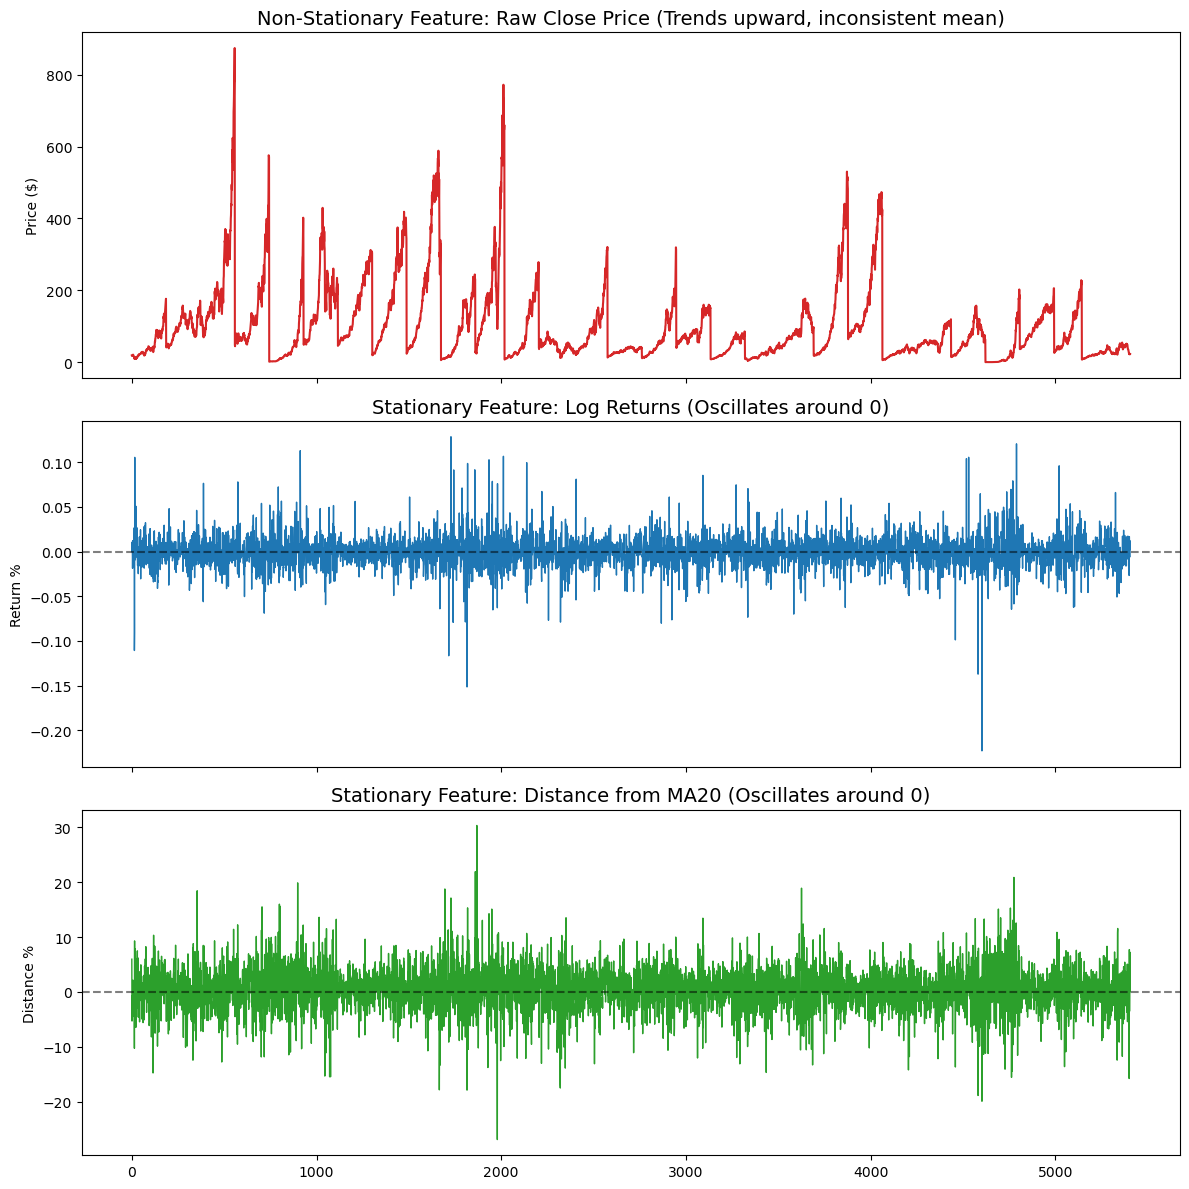

In [ ]:
# quick visualization of why "domain purge" is needed in next step


fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

ax1.plot(df.index, df['Close'], color='tab:red', linewidth=1.5)
ax1.set_title('Non-Stationary Feature: Raw Close Price (Trends upward, inconsistent mean)', fontsize=14)
ax1.set_ylabel('Price ($)')

ax2.plot(df.index, df['Log Returns'], color='tab:blue', linewidth=1)
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax2.set_title('Stationary Feature: Log Returns (Oscillates around 0)', fontsize=14)
ax2.set_ylabel('Return %')

ax3.plot(df.index, df['Distance from MA20'], color='tab:green', linewidth=1)
ax3.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax3.set_title('Stationary Feature: Distance from MA20 (Oscillates around 0)', fontsize=14)
ax3.set_ylabel('Distance %')

plt.tight_layout()
plt.show()

In [161]:
# Domain purge
# why? non stationarity, mean and variance shouldn't drift forever, NVDA could be
# 5$ in 2000 and 200 in 2020, if it learns 200 as a "high price", what happens when price goes up again to 250$
# we see this in the plots that show the price movement for the stocks selected,
# also we see that each stock has a relative price, meanwhile
# log returns and distance from MA20 oscillate around a mean no matter the price of a stock
# as seen in plots, stationary features have real signal that moves around a stationary mean
# much better for models
# things like log returns are relative, a much better measure

domain_purge_list = ['Close', 'High', 
                    'Low', 'Open','MA20', 'MA60',
                    'True Range', 'Daily Range', 
                    'Daily Candle Body', 'Price Difference',
                    'Gains', 'Losses','Average Gains', 
                    'Average Losses','RS']
df = df.drop(columns=domain_purge_list)
df

,Volume,Returns,Log Returns,Monthly Log Returns,Quarterly Log Returns,Semi-annual Log Returns,Daily Volatility,Monthly Volatility,Quarterly Volatility,Semi-annual Volatility,...,Monthly Average Percentage Intraday Range,RSI,14-day Average True Range,Normalized Average True Range,10-day Efficiency Ratio,21-day Efficiency Ratio,Body Up,Body Down,Monthly Conviction Ratio,Target
0,16038300,0.000000,0.000000,0.152737,-0.111184,0.011336,0.015594,0.020631,0.025575,0.022868,...,2.994375,63.398164,0.598177,3.133848,0.974548,0.557497,0.190947,-0.000000,1.573199,0.010587
1,13682700,0.010643,0.010587,-0.114312,-0.094229,-0.133644,0.013959,0.013293,0.019615,0.022269,...,2.081393,37.321298,0.458968,2.628527,0.511865,0.483036,0.212164,-0.000000,0.681006,0.008137
2,21464700,0.008170,0.008137,-0.000405,0.068447,-0.164650,0.015449,0.022657,0.019912,0.023363,...,2.369648,40.295403,0.476924,2.732468,0.517241,0.000989,0.000000,0.007072,0.671463,0.000402
3,18086200,0.000403,0.000402,0.009738,-0.104979,-0.197844,0.008427,0.015688,0.017586,0.021978,...,2.702732,47.477383,0.474413,2.691742,0.042420,0.038572,0.000000,0.028346,1.015751,-0.018632
4,11776300,-0.018459,-0.018632,-0.016624,-0.007290,-0.101520,0.009777,0.021069,0.019709,0.019595,...,2.419379,41.916430,0.473155,2.729605,0.383084,0.042933,0.000000,0.063781,1.180685,-0.004401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5401,8791800,0.016928,0.016786,0.070288,-0.104563,-0.397550,0.015892,0.030433,0.036938,0.036573,...,3.758033,53.985796,0.900604,3.754807,0.436381,0.156221,0.331100,-0.000000,1.060995,0.001746
5402,14368700,0.001748,0.001746,-0.071519,-0.179321,-0.381652,0.017062,0.021932,0.036065,0.036469,...,3.625714,43.446508,0.851715,3.814244,0.406824,0.200000,0.146074,-0.000000,0.670766,0.002099
5403,13052700,0.002101,0.002099,0.006731,0.113902,-0.204354,0.012342,0.037539,0.029200,0.032567,...,3.545709,53.118411,0.909213,3.914670,0.304348,0.013559,0.000000,0.068168,0.625227,0.012234
5404,7253900,0.012309,0.012234,-0.026729,-0.017435,-0.121997,0.010848,0.027957,0.029123,0.033135,...,3.296061,60.322448,0.825024,3.500191,0.189513,0.063021,0.118596,-0.000000,0.824372,-0.005545


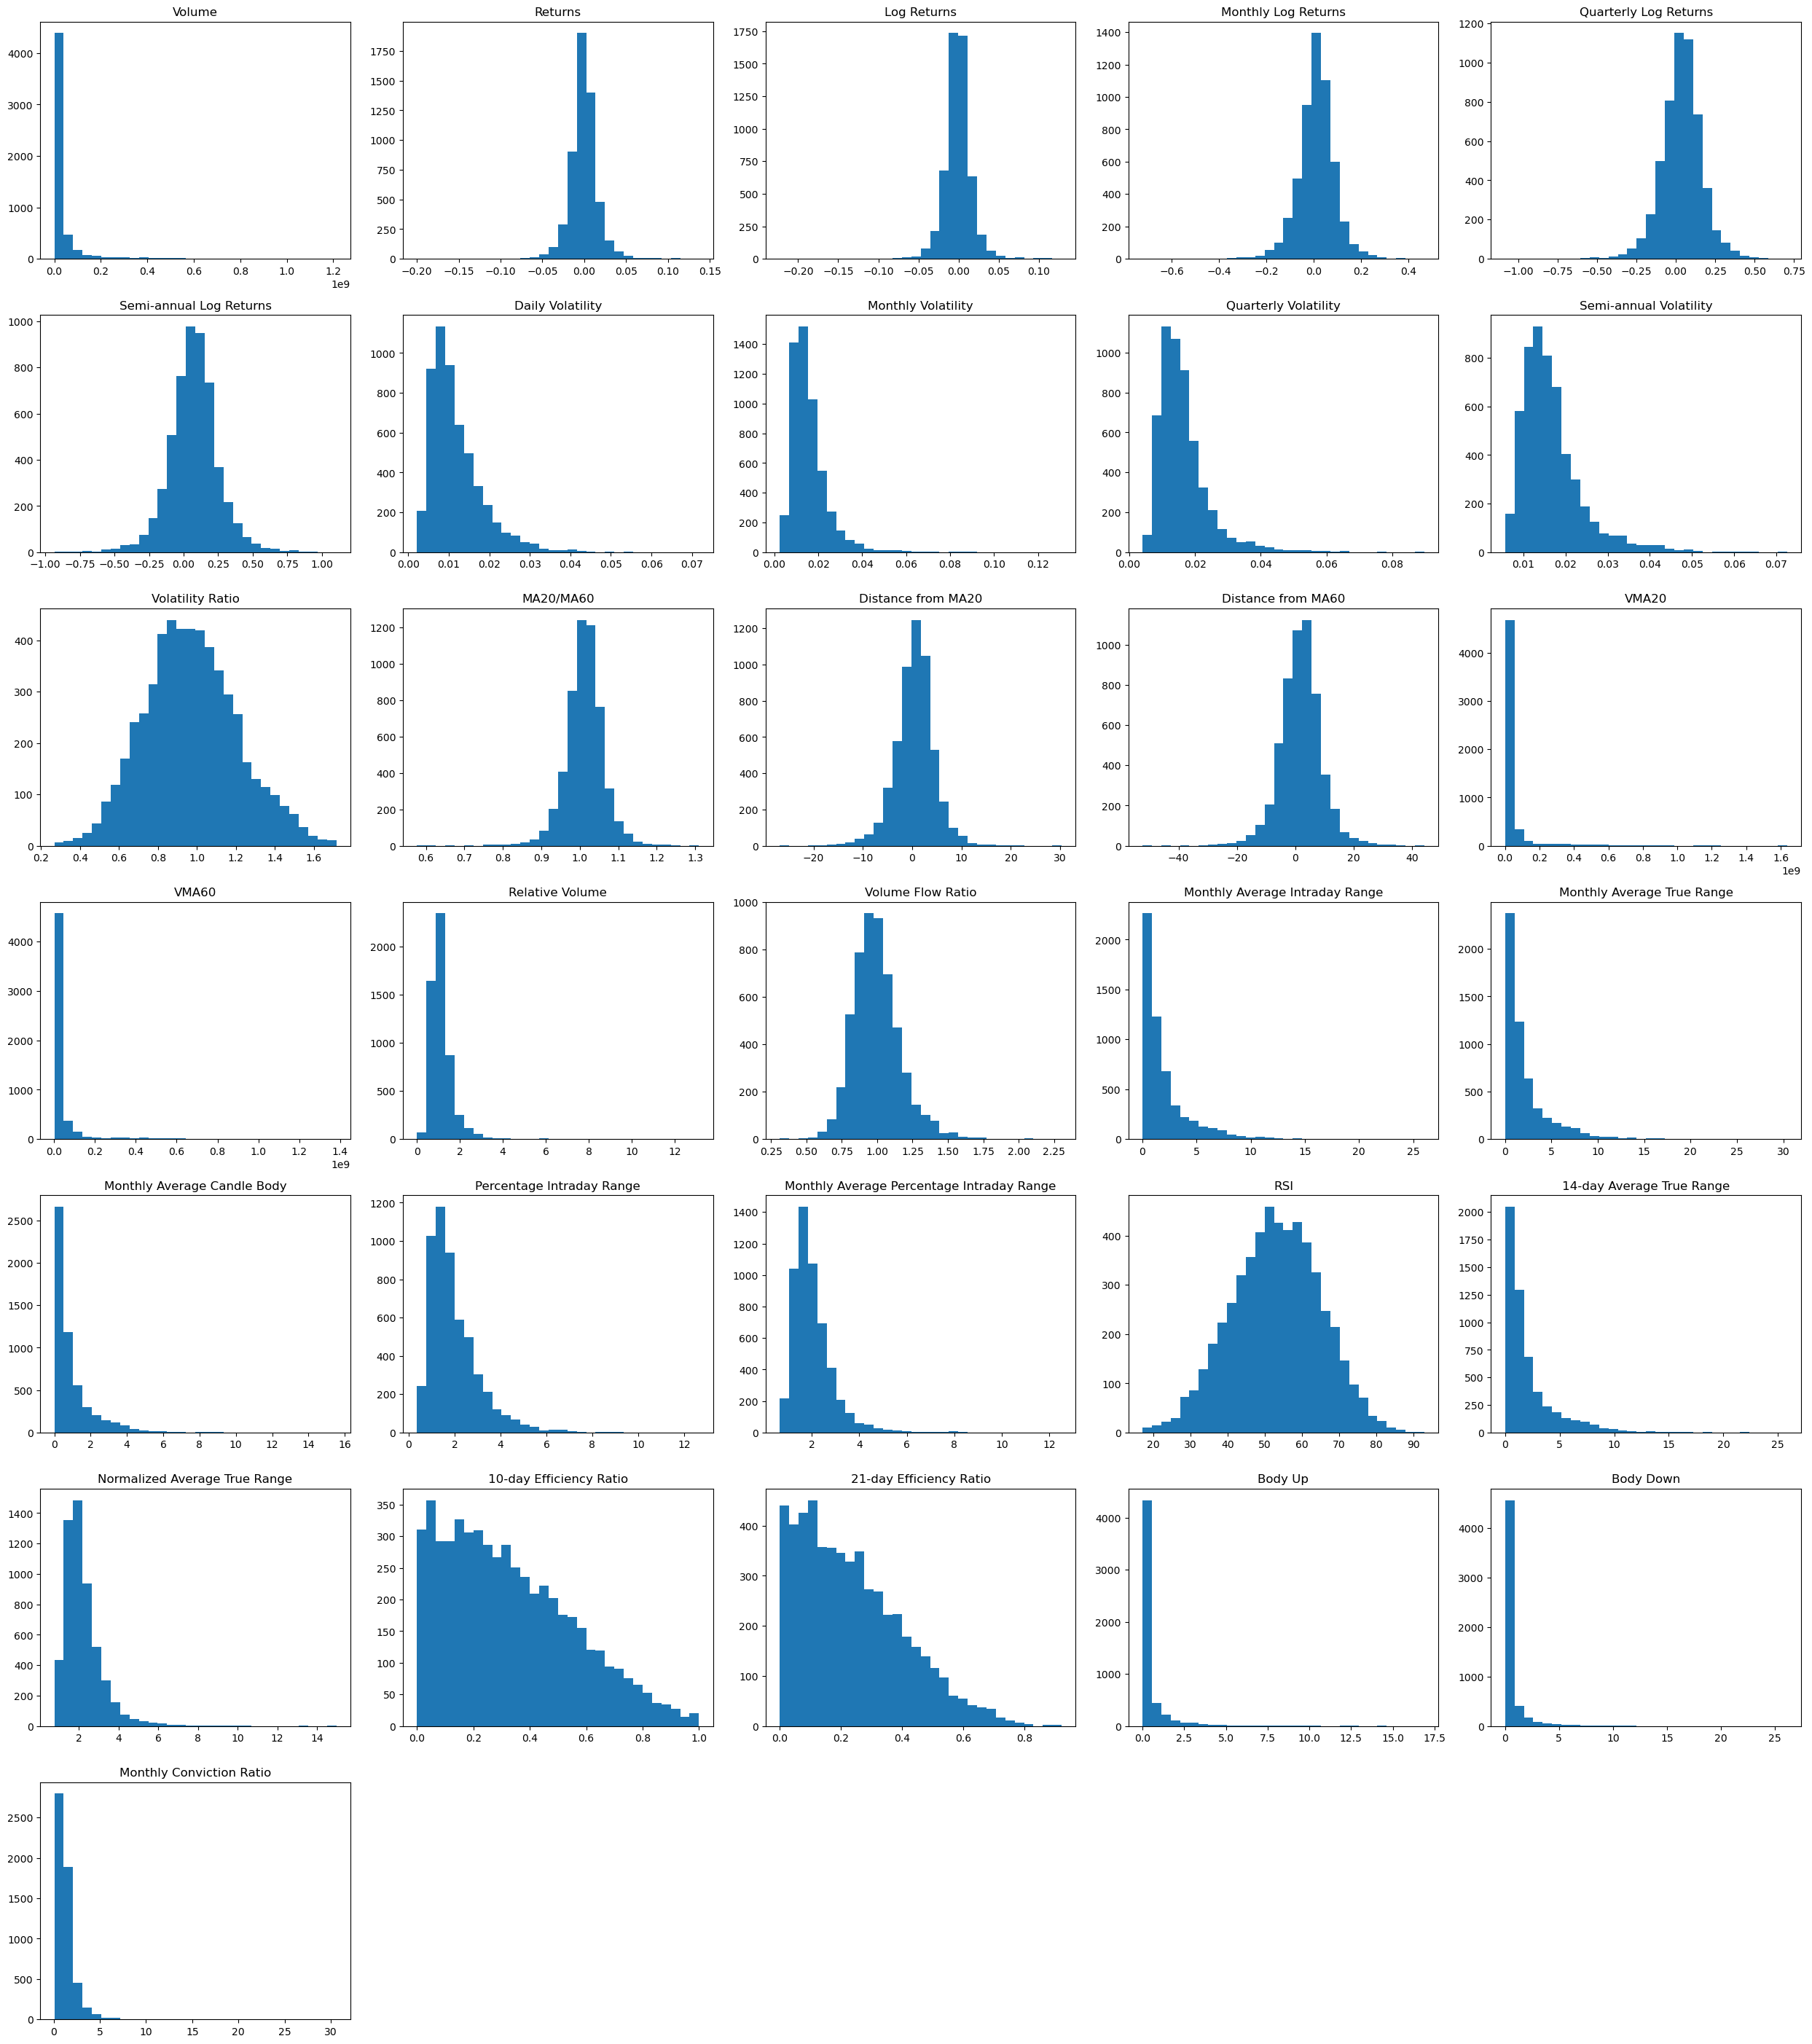

In [95]:
# quick univariate plots of variables now to see how they are before any sort of processing

cols = [c for c in df.columns if c != "Target"]

fig, axes = plt.subplots(n_rows,n_cols,figsize=(5*n_cols,4*n_rows))
axes = axes.flatten()

for i,col in enumerate(cols):
    axes[i].hist(df[col],bins=30)
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [130]:
# we can see from plots that there are features with extreme skewness, data may have extreme outliers
# extreme outliers can be harmful and "treating" skewness will help models find real patterns and not focus solely on large outliers
df.skew()

Volume                                       5.279541
Returns                                      0.208127
Log Returns                                 -0.149804
Monthly Log Returns                         -0.455979
Quarterly Log Returns                       -0.406520
Semi-annual Log Returns                     -0.151652
Daily Volatility                             1.919879
Monthly Volatility                           3.202179
Quarterly Volatility                         2.426719
Semi-annual Volatility                       1.942590
Volatility Ratio                             0.218601
MA20/MA60                                   -0.518479
Distance from MA20                          -0.157715
Distance from MA60                          -0.124203
VMA20                                        5.428637
VMA60                                        5.081590
Relative Volume                              4.629733
Volume Flow Ratio                            0.975599
Monthly Average Intraday Ran

In [131]:
# use threshold of |1| as a good mix between information loss and benefit
# this way we remove over smoothing risk (losing all signal)

df.skew().abs() <= 1

Volume                                       False
Returns                                       True
Log Returns                                   True
Monthly Log Returns                           True
Quarterly Log Returns                         True
Semi-annual Log Returns                       True
Daily Volatility                             False
Monthly Volatility                           False
Quarterly Volatility                         False
Semi-annual Volatility                       False
Volatility Ratio                              True
MA20/MA60                                     True
Distance from MA20                            True
Distance from MA60                            True
VMA20                                        False
VMA60                                        False
Relative Volume                              False
Volume Flow Ratio                             True
Monthly Average Intraday Range               False
Monthly Average True Range     

In [ ]:
# all features with |skew| > 1 have skewness > 1 (positive) so we can log transform
# log(x+1), in case values go to 0, extremely useful for features that exhibit log normal characteristics

skewed = df.skew() >= 1
non_negative = (df >= 0).all()

features = df.columns[skewed & non_negative].tolist()
features

['Volume',
 'Daily Volatility',
 'Monthly Volatility',
 'Quarterly Volatility',
 'Semi-annual Volatility',
 'VMA20',
 'VMA60',
 'Relative Volume',
 'Monthly Average Intraday Range',
 'Monthly Average True Range',
 'Monthly Average Candle Body',
 'Percentage Intraday Range',
 'Monthly Average Percentage Intraday Range',
 '14-day Average True Range',
 'Normalized Average True Range',
 'Body Up',
 'Body Down',
 'Monthly Conviction Ratio']

In [ ]:
df[features] = np.log1p(df[features])
df

,Volume,Returns,Log Returns,Monthly Log Returns,Quarterly Log Returns,Semi-annual Log Returns,Daily Volatility,Monthly Volatility,Quarterly Volatility,Semi-annual Volatility,...,Monthly Average Percentage Intraday Range,RSI,14-day Average True Range,Normalized Average True Range,10-day Efficiency Ratio,21-day Efficiency Ratio,Body Up,Body Down,Monthly Conviction Ratio,Target
0,16.590490,0.000000,0.000000,0.152737,-0.111184,0.011336,0.015474,0.020421,0.025254,0.022611,...,1.384887,63.398164,0.468863,1.419209,0.974548,0.557497,0.174749,-0.000000,0.945150,0.010587
1,16.431643,0.010643,0.010587,-0.114312,-0.094229,-0.133644,0.013862,0.013205,0.019425,0.022024,...,1.125382,37.321298,0.377729,1.288827,0.511865,0.483036,0.192407,-0.000000,0.519393,0.008137
2,16.881920,0.008170,0.008137,-0.000405,0.068447,-0.164650,0.015331,0.022404,0.019716,0.023095,...,1.214808,40.295403,0.389961,1.317070,0.517241,0.000989,0.000000,0.007047,0.513699,0.000402
3,16.710660,0.000403,0.000402,0.009738,-0.104979,-0.197844,0.008391,0.015566,0.017433,0.021740,...,1.309071,47.477383,0.388260,1.306098,0.042420,0.038572,0.000000,0.027952,0.700992,-0.018632
4,16.281600,-0.018459,-0.018632,-0.016624,-0.007290,-0.101520,0.009730,0.020850,0.019518,0.019406,...,1.229459,41.916430,0.387407,1.316302,0.383084,0.042933,0.000000,0.061829,0.779639,-0.004401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5401,15.989330,0.016928,0.016786,0.070288,-0.104563,-0.397550,0.015767,0.029979,0.036272,0.035920,...,1.559834,53.985796,0.642172,1.559156,0.436381,0.156221,0.286005,-0.000000,0.723189,0.001746
5402,16.480563,0.001748,0.001746,-0.071519,-0.179321,-0.381652,0.016918,0.021695,0.035430,0.035820,...,1.531631,43.446508,0.616112,1.571579,0.406824,0.200000,0.136342,-0.000000,0.513282,0.002099
5403,16.384506,0.002101,0.002099,0.006731,0.113902,-0.204354,0.012266,0.036852,0.028781,0.032048,...,1.514184,53.118411,0.646691,1.592225,0.304348,0.013559,0.000000,0.065945,0.485647,0.012234
5404,15.797050,0.012309,0.012234,-0.026729,-0.017435,-0.121997,0.010790,0.027573,0.028707,0.032597,...,1.457699,60.322448,0.601593,1.504120,0.189513,0.063021,0.112074,-0.000000,0.601236,-0.005545


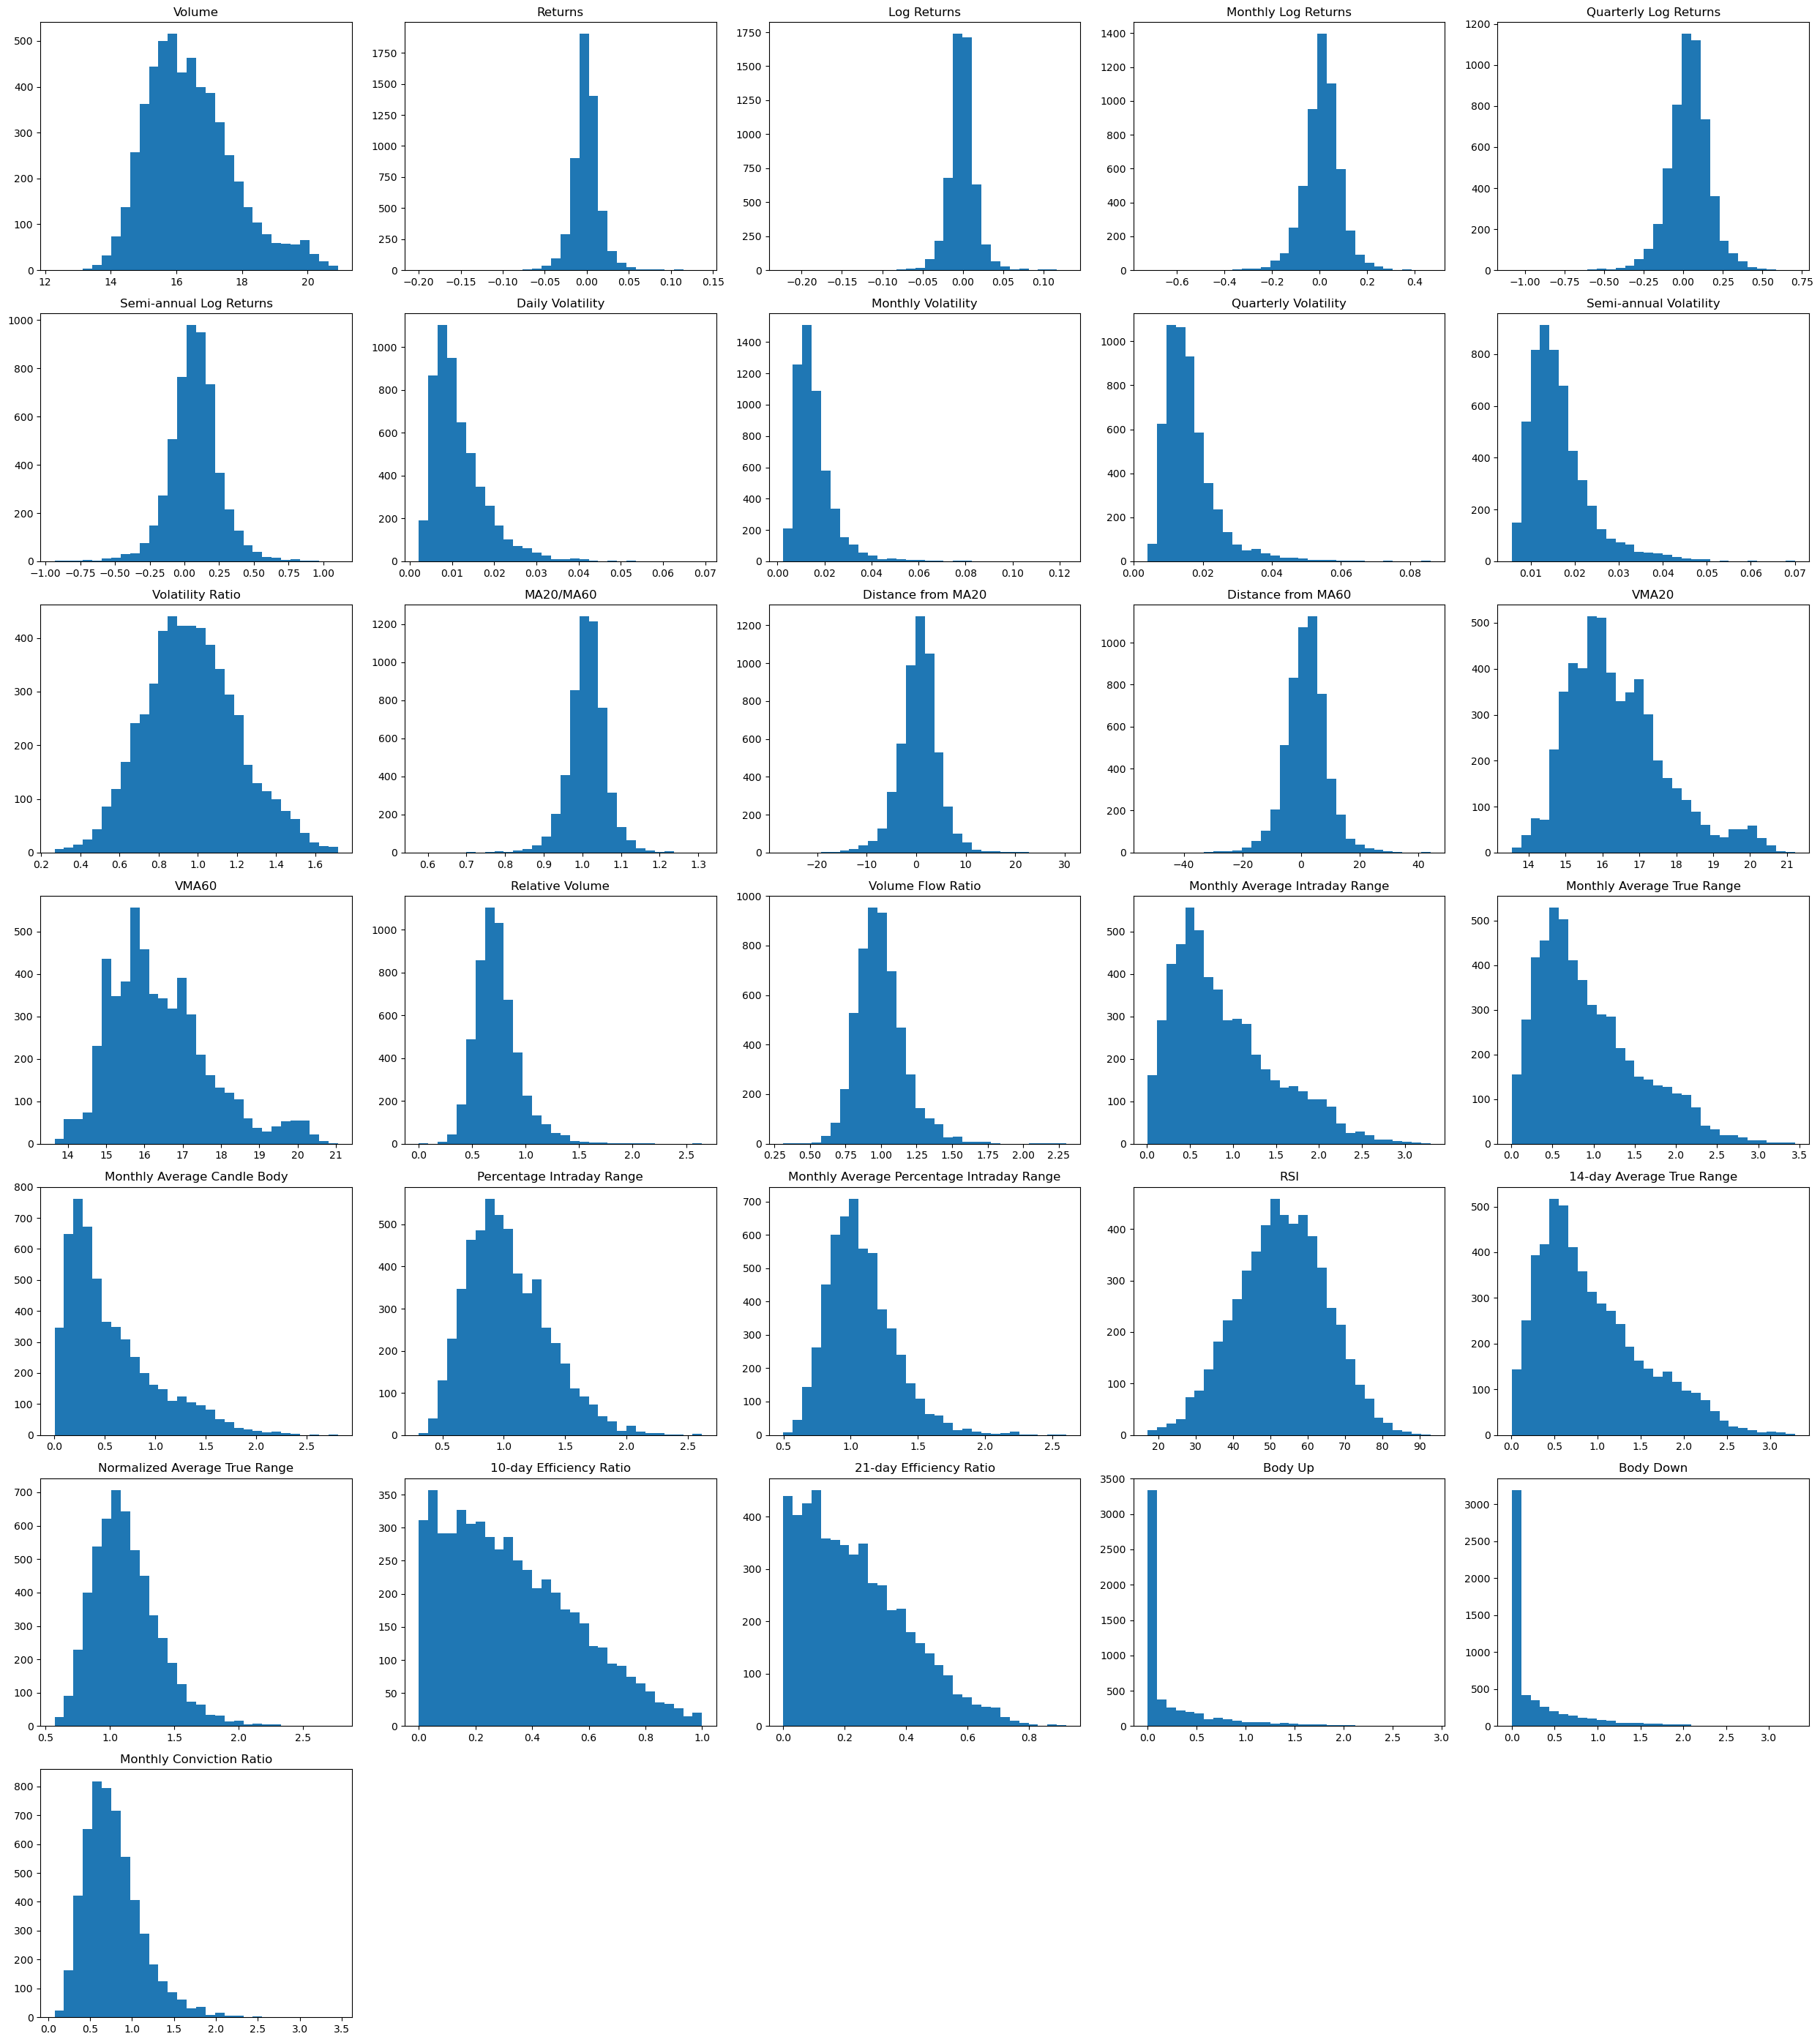

In [100]:
# move onto EDA and statistical testing, first univariate, then bivariate
# univariate

cols = [c for c in df.columns if c != "Target"]
n_cols = 5
n_rows = math.ceil(len(cols)/n_cols)

fig, axes = plt.subplots(n_rows,n_cols,figsize=(5*n_cols,4*n_rows))
axes = axes.flatten()

for i,col in enumerate(cols):
    axes[i].hist(df[col],bins=30)
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

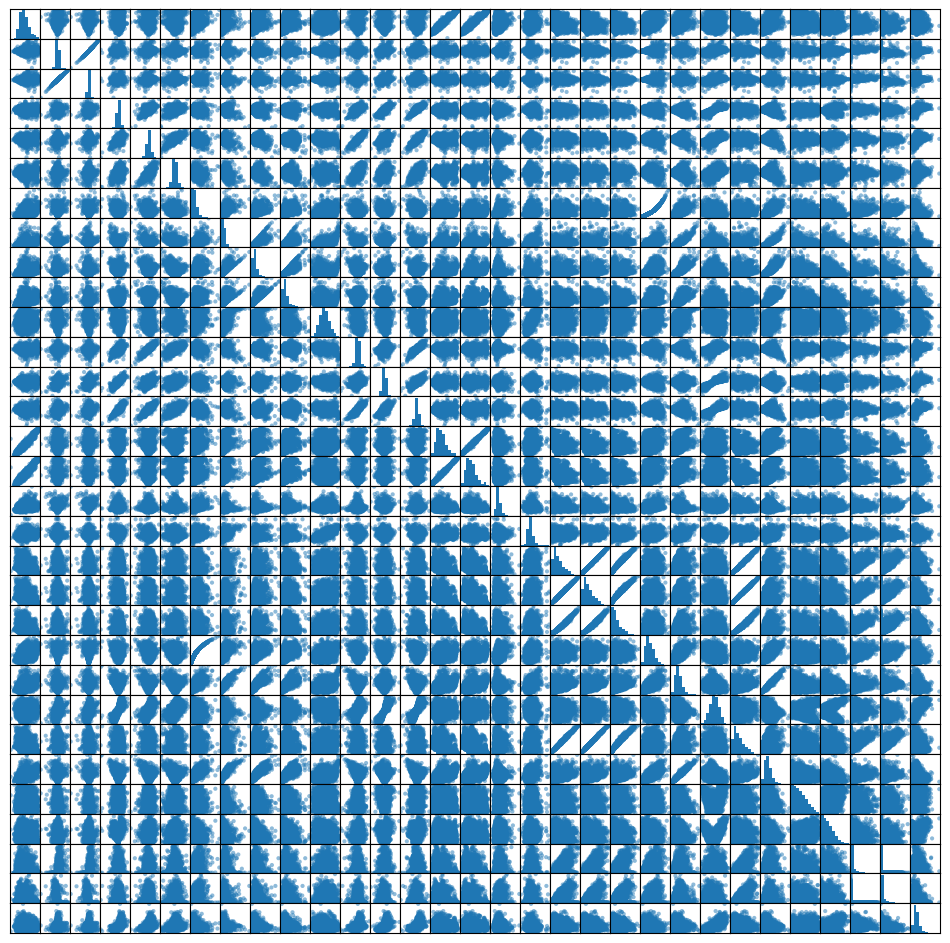

In [101]:
# we can now see that even though some features are still quite skewed, we can see more "normal" distribution, "unlocking" more signal

# now we check for correlation between features, 31 is not too many features, but checking for redundancy / correlation is always good
# using all of them might make models suffer from multicollinearity
# plot features against each other to see correlations visually

axes = scatter_matrix(df[cols], figsize=(12,12))

for ax in axes.flatten():
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()

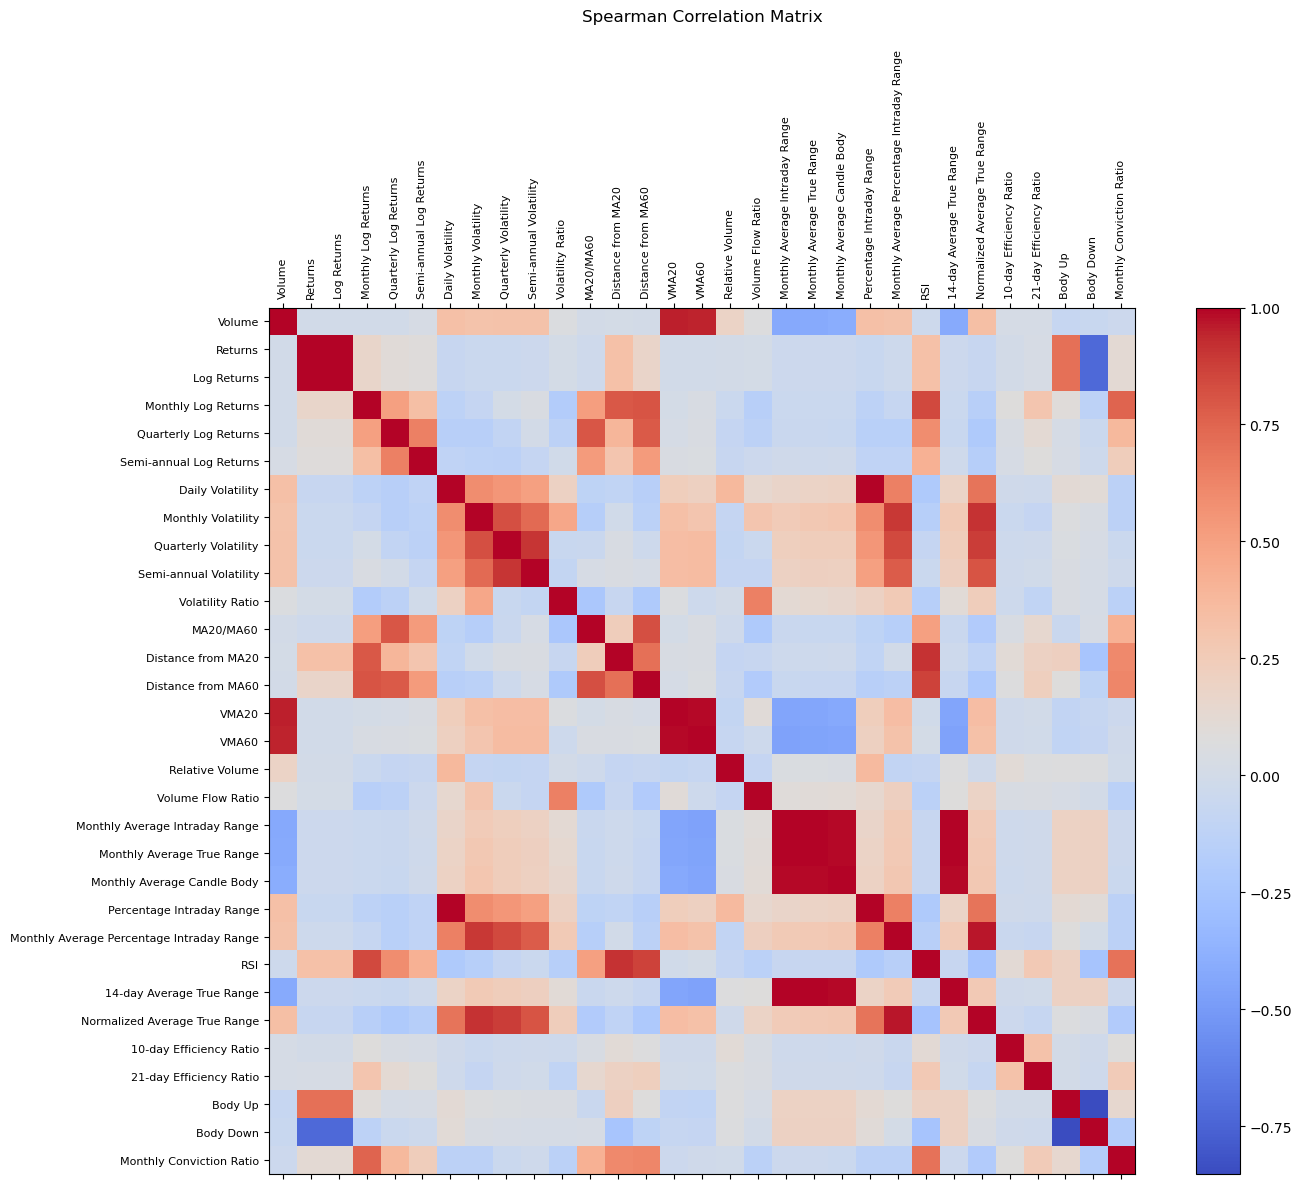

In [102]:
# we can see that there are features that have high correaltion with one another
# even though we "treated" skewness, we still have some features with outliers
# pearson coefficient is very sensitive to outliers, so Spearmen will be used, more "immune" to outliers
# spearmen also works better at capturing non linear relationships, which are more common in financial data


corr_matrix = df.drop(columns=['Target']).corr(method='spearman')
fig, ax = plt.subplots(figsize=(15, 12))
cax = ax.matshow(corr_matrix, cmap='coolwarm')
fig.colorbar(cax)
ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=90, fontsize=8)
ax.set_yticklabels(corr_matrix.columns, fontsize=8)

plt.title("Spearman Correlation Matrix", pad=20)
plt.tight_layout()
plt.show()

In [134]:
# for correlation ,we will use a threshold of 0.9, which indicates the features share about 81% of their variance

high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > 0.9:  # check for strong correlation
            pair = (corr_matrix.columns[i], corr_matrix.columns[j], corr_value)
            high_corr_pairs.append(pair)

high_corr_pairs = sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True)

for pair in high_corr_pairs:
    print(f"{pair[0]} - {pair[1]}: {pair[2]:.2f}")


Returns - Log Returns: 1.00
Daily Volatility - Percentage Intraday Range: 1.00
Monthly Average Intraday Range - Monthly Average True Range: 1.00
Monthly Average True Range - 14-day Average True Range: 1.00
Monthly Average Intraday Range - 14-day Average True Range: 1.00
Monthly Average Intraday Range - Monthly Average Candle Body: 0.99
Monthly Average True Range - Monthly Average Candle Body: 0.99
VMA20 - VMA60: 0.99
Monthly Average Candle Body - 14-day Average True Range: 0.99
Monthly Average Percentage Intraday Range - Normalized Average True Range: 0.97
Volume - VMA20: 0.95
Volume - VMA60: 0.94
Monthly Volatility - Normalized Average True Range: 0.91
Distance from MA20 - RSI: 0.91
Quarterly Volatility - Semi-annual Volatility: 0.91


In [135]:
# we have various candidates for highly correlated features
# between returns and log returns we will keep log-returns as they are mathematically more beneficial
# also our target is the log returns, returns is removed

# we now analyze the rest, using histograms for visuals and 
# Composite Normality Metric: the sum of absolute values of skewness and kurtosis

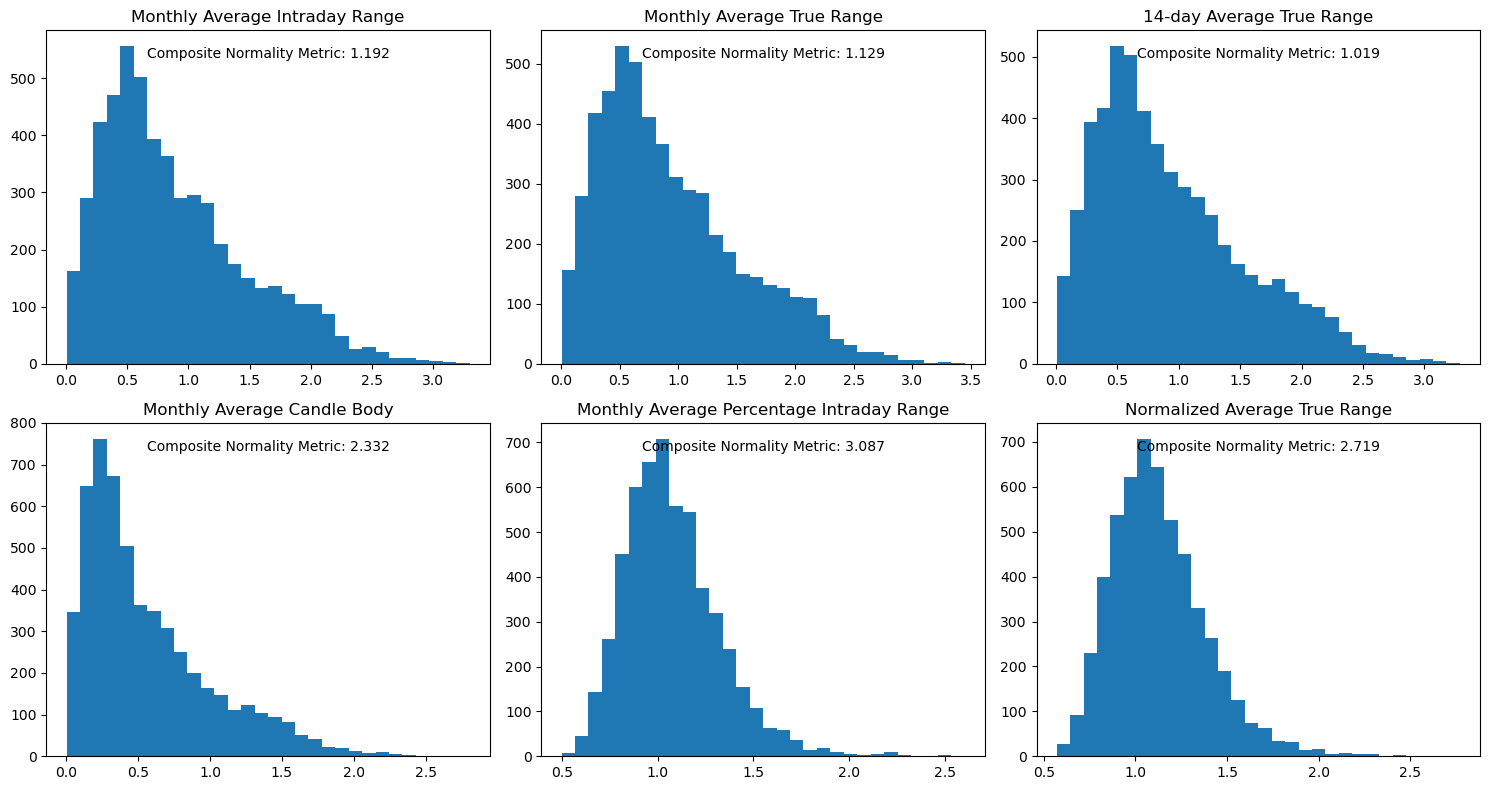

In [136]:
# first the "range" family
# Monthly Average Intraday Range - Monthly Average True Range: 1.00
# Monthly Average True Range - 14-day Average True Range: 1.00
# Monthly Average Intraday Range - 14-day Average True Range: 1.00
# Monthly Average Intraday Range - Monthly Average Candle Body: 0.99
# Monthly Average True Range - Monthly Average Candle Body: 0.99
# Monthly Average Candle Body - 14-day Average True Range: 0.99
# Monthly Average Percentage Intraday Range - Normalized Average True Range: 0.97

cols = [
    "Monthly Average Intraday Range",
    "Monthly Average True Range",
    "14-day Average True Range",
    "Monthly Average Candle Body",
    "Monthly Average Percentage Intraday Range",
    "Normalized Average True Range"
]
n_cols = 3
n_rows = math.ceil(len(cols)/n_cols)

fig, axes = plt.subplots(n_rows,n_cols,figsize=(5*n_cols,4*n_rows))
axes = axes.flatten()

for i,col in enumerate(cols):
    axes[i].hist(df[col],bins=30)
    axes[i].set_title(col)
    score = abs(df[col].skew()) + abs(df[col].kurt())
    axes[i].text(0.5, 0.95, f'Composite Normality Metric: {score:.3f}',
             transform=axes[i].transAxes,
             ha='center', va='top')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [137]:
# the first 3 plots are nearly identical, we keep 14 day average intraday range as it has lowest "score"
# so we remove monthly average intraday range, monthly average true range and monthly average candle body as they are all highly correlated to 14 day
# between monthly average percentage intraday range and normalized average true range, remove the first as it has higher "score"



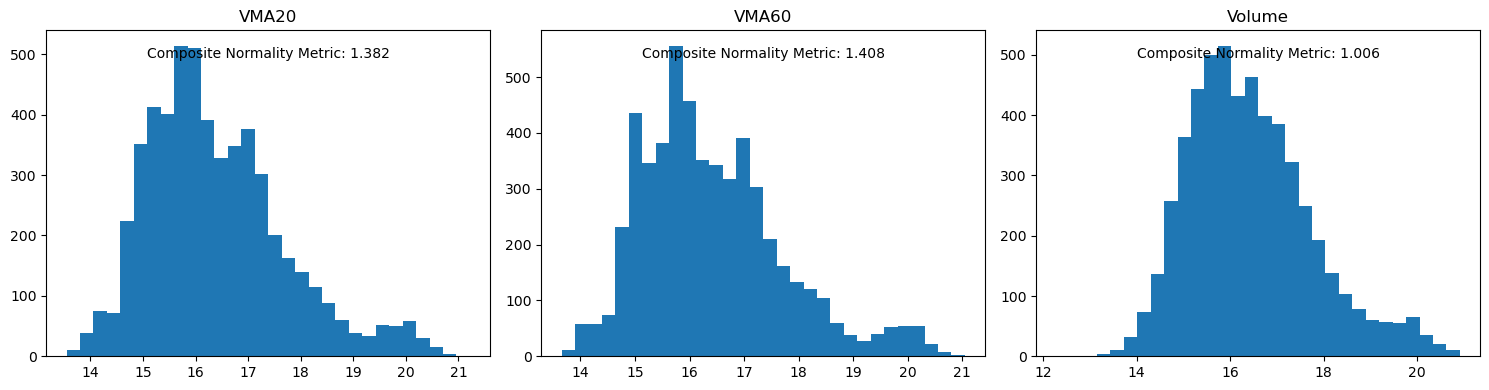

In [138]:
# move onto the volume family
# VMA20 - VMA60: 0.99
# Volume - VMA20: 0.95
# Volume - VMA60: 0.94

cols = [
    "VMA20",
    "VMA60",
    "Volume"
]
n_cols = 3

fig, axes = plt.subplots(1,n_cols,figsize=(15,4))
axes = axes.flatten()

for i,col in enumerate(cols):
    axes[i].hist(df[col],bins=30)
    axes[i].set_title(col)
    score = abs(df[col].skew()) + abs(df[col].kurt())
    axes[i].text(0.5, 0.95, f'Composite Normality Metric: {score:.3f}',
             transform=axes[i].transAxes,
             ha='center', va='top')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()




In [139]:
# volume stays as it has lowest "score"
# won't discard both VMA now, will leave one for future tests
# will keep VMA20 as it has better score and aligns more with target variable time frame, VMA60 is removed

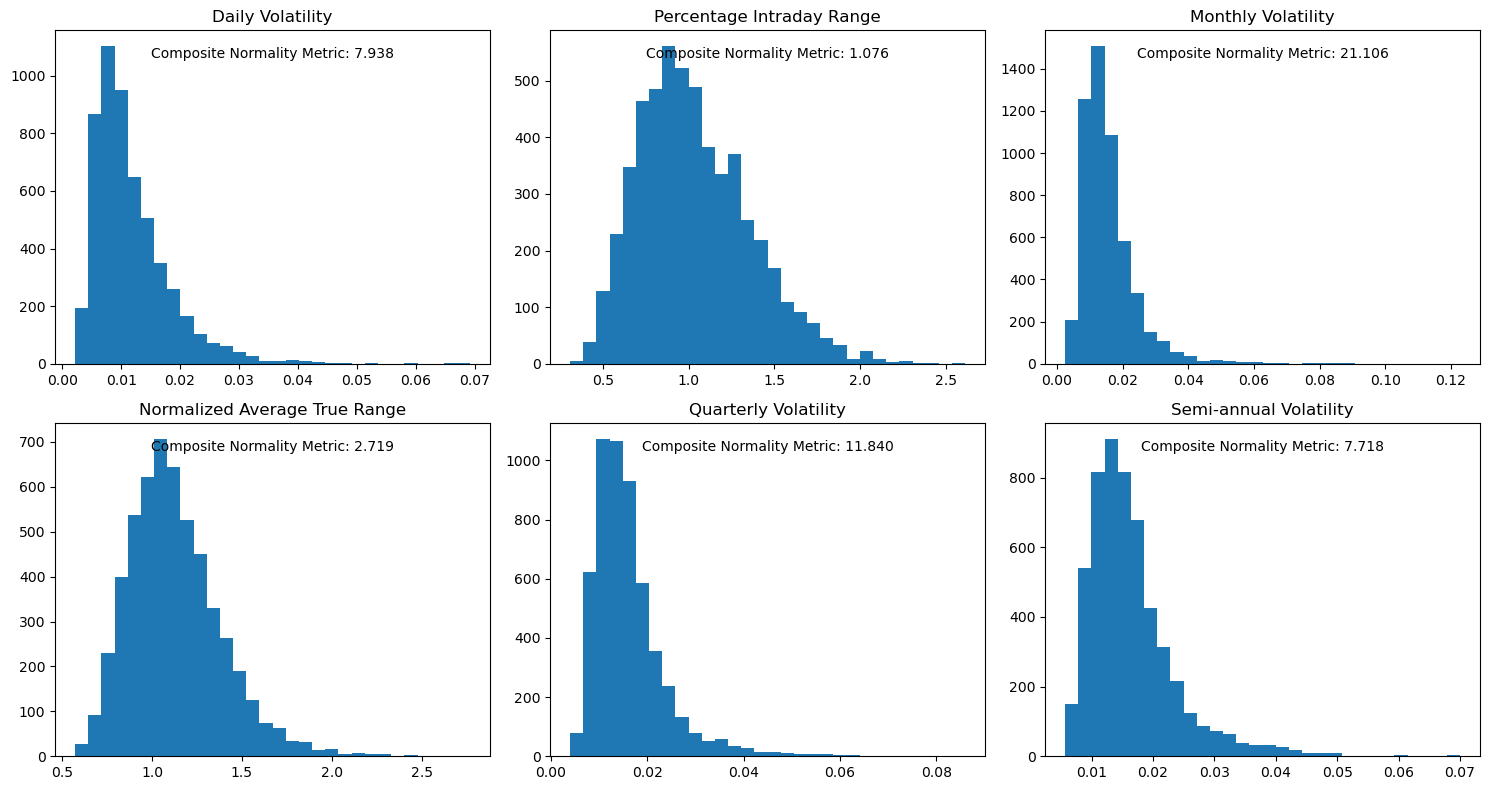

In [140]:
# next is volatility group
# Daily Volatility - Percentage Intraday Range: 1.00
# Monthly Volatility - Normalized Average True Range: 0.91
# Quarterly Volatility - Semi-annual Volatility: 0.91

cols = [
    "Daily Volatility",
    "Percentage Intraday Range",
    "Monthly Volatility",
    "Normalized Average True Range",
    "Quarterly Volatility",
    "Semi-annual Volatility"
]

n_cols = 3
n_rows = math.ceil(len(cols)/n_cols)

fig, axes = plt.subplots(n_rows,n_cols,figsize=(5*n_cols,4*n_rows))
axes = axes.flatten()

for i,col in enumerate(cols):
    axes[i].hist(df[col],bins=30)
    axes[i].set_title(col)
    score = abs(df[col].skew()) + abs(df[col].kurt())
    axes[i].text(0.5, 0.95, f'Composite Normality Metric: {score:.3f}',
             transform=axes[i].transAxes,
             ha='center', va='top')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [141]:
# percentage intraday range is much more normal then daily volatilty, daily volatility is removed
# we already kept normalized average true range, it stays, but we also keep monthly volatility as it aligns with target timeframe,
# may be removed in later tests
# between quarterly volatility and semi annual, semi annual stays

Distance from MA20: 3.1241752772943947
RSI: 0.34724523584104117


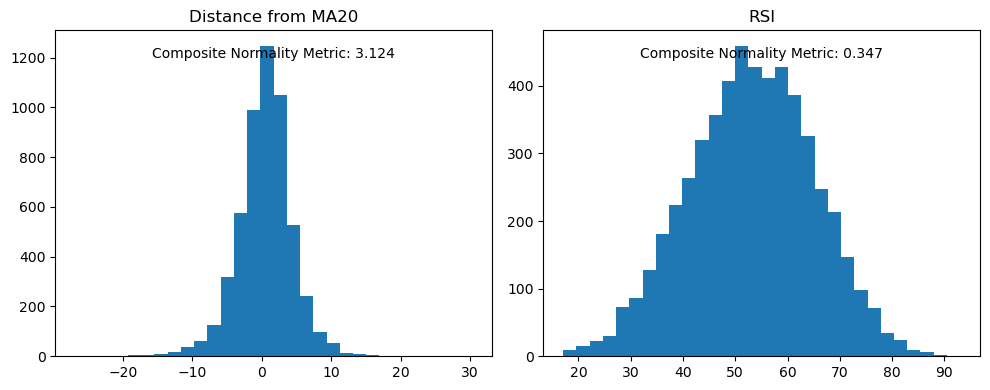

In [142]:
# last correlation test
# Distance from MA20 - RSI: 0.91

cols = ['Distance from MA20', 'RSI']

n_cols = 2

fig, axes = plt.subplots(1,n_cols,figsize=(10,4))
axes = axes.flatten()

for i,col in enumerate(cols):
    axes[i].hist(df[col],bins=30)
    axes[i].set_title(col)
    score = abs(df[col].skew()) + abs(df[col].kurt())
    print(f'{col}: {score}')
    axes[i].text(0.5, 0.95, f'Composite Normality Metric: {score:.3f}',
             transform=axes[i].transAxes,
             ha='center', va='top')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [164]:
# distance from MA20 has clearly higher kurtosis, much higher "normality" score
# we keep RSI

# final list to remove after correlation tests:

features = [
    "Returns",
    "Monthly Average Intraday Range",
    "Monthly Average True Range",
    "Monthly Average Candle Body",
    "Monthly Average Percentage Intraday Range",
    "VMA60",
    "Daily Volatility",
    "Quarterly Volatility",
    "Distance from MA20"
]

df = df.drop(columns=features)
df

,Volume,Log Returns,Monthly Log Returns,Quarterly Log Returns,Semi-annual Log Returns,Monthly Volatility,Semi-annual Volatility,Volatility Ratio,MA20/MA60,Distance from MA60,...,Percentage Intraday Range,RSI,14-day Average True Range,Normalized Average True Range,10-day Efficiency Ratio,21-day Efficiency Ratio,Body Up,Body Down,Monthly Conviction Ratio,Target
0,16.590490,0.000000,0.152737,-0.111184,0.011336,0.020421,0.022611,0.806682,0.985594,4.438090,...,1.286407,63.398164,0.468863,1.419209,0.974548,0.557497,0.174749,-0.000000,0.945150,0.010587
1,16.431643,0.010587,-0.114312,-0.094229,-0.133644,0.013205,0.022024,0.677686,1.019081,-3.484442,...,1.205079,37.321298,0.377729,1.288827,0.511865,0.483036,0.192407,-0.000000,0.519393,0.008137
2,16.881920,0.008137,-0.000405,0.068447,-0.164650,0.022404,0.023095,1.137834,0.999165,-5.198120,...,1.278750,40.295403,0.389961,1.317070,0.517241,0.000989,0.000000,0.007047,0.513699,0.000402
3,16.710660,0.000402,0.009738,-0.104979,-0.197844,0.015566,0.021740,0.892082,0.978417,-2.771445,...,0.877575,47.477383,0.388260,1.306098,0.042420,0.038572,0.000000,0.027952,0.700992,-0.018632
4,16.281600,-0.018632,-0.016624,-0.007290,-0.101520,0.020850,0.019406,1.069011,1.005133,-4.052603,...,0.966728,41.916430,0.387407,1.316302,0.383084,0.042933,0.000000,0.061829,0.779639,-0.004401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5401,15.989330,0.016786,0.070288,-0.104563,-0.397550,0.029979,0.035920,0.823890,0.880420,-5.167513,...,1.301824,53.985796,0.642172,1.559156,0.436381,0.156221,0.286005,-0.000000,0.723189,0.001746
5402,16.480563,0.001746,-0.071519,-0.179321,-0.381652,0.021695,0.035820,0.608122,0.971031,-6.304750,...,1.340944,43.446508,0.616112,1.571579,0.406824,0.200000,0.136342,-0.000000,0.513282,0.002099
5403,16.384506,0.002099,0.006731,0.113902,-0.204354,0.036852,0.032048,1.285608,0.982339,2.175260,...,1.114648,53.118411,0.646691,1.592225,0.304348,0.013559,0.000000,0.065945,0.485647,0.012234
5404,15.797050,0.012234,-0.026729,-0.017435,-0.121997,0.027573,0.032597,0.959965,0.978368,4.920278,...,1.033915,60.322448,0.601593,1.504120,0.189513,0.063021,0.112074,-0.000000,0.601236,-0.005545


In [165]:
# were down to 22 features, much better
df.shape[1] - 1

22

In [166]:
# now onto VIF (variance inflation factor)
# measures correlation between 1 to many features instead of 1-1
# measures how much of the "information" in a feature is contained within the rest of the dataset
# will use a iterative step down approach


cols = [c for c in df.columns if c != "Target"]
X = df[cols].copy()
X["Intercept"] = 1
vif_data = pd.DataFrame()
vif_data["Feature"] = cols
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(cols))]
vif_data.sort_values("VIF", ascending=False)


,Feature,VIF
0,Volume,216.248459
10,VMA20,212.270953
9,Distance from MA60,27.432214
11,Relative Volume,17.545269
16,Normalized Average True Range,10.844974
8,MA20/MA60,9.714841
5,Monthly Volatility,8.387962
14,RSI,7.570293
2,Monthly Log Returns,5.708514
3,Quarterly Log Returns,5.114222


In [167]:
# VMA20 has a very large VIF, its signal is contained in other features
# althoug volume has even igher VIF, this can happen with two very highly correlated features
# VMA20 was kept to see if it could add, but it was going to be removed before volatility
# once VMA20 is removed VIF for volatility will reduce drastically
# for reference, a VIF of 10 is an R^2 of 0.9 as VIF = 1 / (1 - R^2)
# R^2 being the r squared value of regressing feature i on all other features
# this would imply 90% of information in that feature is already contained in other features

df = df.drop(columns=["VMA20"])

cols = [c for c in df.columns if c != "Target"]
X = df[cols].copy()
X["Intercept"] = 1
vif_data = pd.DataFrame()
vif_data["Feature"] = cols
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(cols))]
vif_data.sort_values("VIF", ascending=False)

,Feature,VIF
9,Distance from MA60,27.412234
15,Normalized Average True Range,10.832082
8,MA20/MA60,9.702351
5,Monthly Volatility,8.374073
13,RSI,7.566814
2,Monthly Log Returns,5.707650
3,Quarterly Log Returns,5.111693
6,Semi-annual Volatility,4.946669
12,Percentage Intraday Range,4.379539
14,14-day Average True Range,3.829303


In [ ]:
# volume VIF drops to 1.8 now
# a VIF of 27 means that about 96.3% of the information in "Distance from MA60" is 
# already represented by the other trend and volatility indicators

df = df.drop(columns=["Distance from MA60"])

cols = [c for c in df.columns if c != "Target"]
X = df[cols].copy()
X["Intercept"] = 1
vif_data = pd.DataFrame()
vif_data["Feature"] = cols
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(cols))]
vif_data.sort_values("VIF", ascending=False)

,Feature,VIF
14,Normalized Average True Range,10.777387
5,Monthly Volatility,8.140008
6,Semi-annual Volatility,4.945723
3,Quarterly Log Returns,4.877308
11,Percentage Intraday Range,4.375061
12,RSI,4.135362
8,MA20/MA60,3.870131
13,14-day Average True Range,3.829269
17,Body Up,3.406968
18,Body Down,3.378691


In [ ]:
# Monthly Average Percentage Intraday Range had a low "Normality Score" (0.818) and its just borderline over
# the VIF < 10 threshold, but the rest of features are bloew even with this feature included so
# we will keep it for now, but its MI will make the final decision

In [171]:
# we have what could be called an orthogonal feature set

df.columns

Index(['Volume', 'Log Returns', 'Monthly Log Returns', 'Quarterly Log Returns',
       'Semi-annual Log Returns', 'Monthly Volatility',
       'Semi-annual Volatility', 'Volatility Ratio', 'MA20/MA60',
       'Relative Volume', 'Volume Flow Ratio', 'Percentage Intraday Range',
       'RSI', '14-day Average True Range', 'Normalized Average True Range',
       '10-day Efficiency Ratio', '21-day Efficiency Ratio', 'Body Up',
       'Body Down', 'Monthly Conviction Ratio', 'Target'],
      dtype='str')

In [ ]:
# 20 features left
# the final step will be testing for Mutual information
# it doesn't look for correlations instead looks for information gained from each feature
# won't find redundancy, will find relevancy of features

In [176]:
# won't be using traditional MI as it requires discrete bins for variables
# this binning can be subjective and can destroy signal in data
# using KSG estimator (knn based approach) can identify complex structures
# without discretization, can capture non linear trends
# can be sensitive with number of samples, but as we are using "stacked" dataset, not an issue


X = df.drop(columns=["Target"])
y = df["Target"]
mi_scores = mutual_info_regression(X, y, discrete_features=False, random_state=42)
mi_results = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
print("--- Mutual Information Ranking ---")
print(mi_results)

--- Mutual Information Ranking ---
Monthly Volatility               0.046699
Normalized Average True Range    0.040285
Semi-annual Volatility           0.037633
Semi-annual Log Returns          0.025211
Percentage Intraday Range        0.022635
Volatility Ratio                 0.020886
Volume                           0.017190
21-day Efficiency Ratio          0.012210
MA20/MA60                        0.011030
Quarterly Log Returns            0.009611
Log Returns                      0.008429
10-day Efficiency Ratio          0.004596
RSI                              0.003745
Monthly Log Returns              0.001757
Volume Flow Ratio                0.000000
Relative Volume                  0.000000
14-day Average True Range        0.000000
Body Up                          0.000000
Body Down                        0.000000
Monthly Conviction Ratio         0.000000
dtype: float64


In [ ]:
# remove all with MI = 0
# shows "candlestick" data or trading isnt indicative of returns
# despite most features having low MI, which is quite normal in financial data, they have predictive power
# but it may be quite low or it may be in combination with other features
# risk of low MI can be overfitting to noise, but with a large dataset like ours it can be controlled

features = [
    "Volume Flow Ratio",
    "Relative Volume",
    "14-day Average True Range",
    "Body Up",
    "Body Down",
    "Monthly Conviction Ratio"
]

df = df.drop(columns=features)
df

,Volume,Log Returns,Monthly Log Returns,Quarterly Log Returns,Semi-annual Log Returns,Monthly Volatility,Semi-annual Volatility,Volatility Ratio,MA20/MA60,Percentage Intraday Range,RSI,Normalized Average True Range,10-day Efficiency Ratio,21-day Efficiency Ratio,Target
0,16.590490,0.000000,0.152737,-0.111184,0.011336,0.020421,0.022611,0.806682,0.985594,1.286407,63.398164,1.419209,0.974548,0.557497,0.010587
1,16.431643,0.010587,-0.114312,-0.094229,-0.133644,0.013205,0.022024,0.677686,1.019081,1.205079,37.321298,1.288827,0.511865,0.483036,0.008137
2,16.881920,0.008137,-0.000405,0.068447,-0.164650,0.022404,0.023095,1.137834,0.999165,1.278750,40.295403,1.317070,0.517241,0.000989,0.000402
3,16.710660,0.000402,0.009738,-0.104979,-0.197844,0.015566,0.021740,0.892082,0.978417,0.877575,47.477383,1.306098,0.042420,0.038572,-0.018632
4,16.281600,-0.018632,-0.016624,-0.007290,-0.101520,0.020850,0.019406,1.069011,1.005133,0.966728,41.916430,1.316302,0.383084,0.042933,-0.004401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5401,15.989330,0.016786,0.070288,-0.104563,-0.397550,0.029979,0.035920,0.823890,0.880420,1.301824,53.985796,1.559156,0.436381,0.156221,0.001746
5402,16.480563,0.001746,-0.071519,-0.179321,-0.381652,0.021695,0.035820,0.608122,0.971031,1.340944,43.446508,1.571579,0.406824,0.200000,0.002099
5403,16.384506,0.002099,0.006731,0.113902,-0.204354,0.036852,0.032048,1.285608,0.982339,1.114648,53.118411,1.592225,0.304348,0.013559,0.012234
5404,15.797050,0.012234,-0.026729,-0.017435,-0.121997,0.027573,0.032597,0.959965,0.978368,1.033915,60.322448,1.504120,0.189513,0.063021,-0.005545


In [ ]:
# 14 features isn't necessarily low, the low MI indicates our dataset might not be sufficiently predictive by itself right now
# most of the features are "internal" market technical indicators, but these don't move price, they simply describe how it moves
# may be difficult to predict future returns without context for these indicators
# will continue investigation by adding in more features, seeing if they positively help
# if so, data processing methods will be modified in the "real" pipeline to include new features
# these notebooks are just investigation, not clean, they show the real "flow" of the process, while the pipeline will show the final clean result
df.columns

Index(['Volume', 'Log Returns', 'Monthly Log Returns', 'Quarterly Log Returns',
       'Semi-annual Log Returns', 'Monthly Volatility',
       'Semi-annual Volatility', 'Volatility Ratio', 'MA20/MA60',
       'Percentage Intraday Range', 'RSI', 'Normalized Average True Range',
       '10-day Efficiency Ratio', '21-day Efficiency Ratio', 'Target'],
      dtype='str')

In [6]:
# so this part will be like an extension of the signal generation notebook

df1 = dl.load_single_data("processed","AAPL")

AAPL.csv loaded succesfully


In [7]:
df1.head()

,Close,High,Low,Open,Volume,Returns,Log Returns,Monthly Log Returns,Quarterly Log Returns,Semi-annual Log Returns,...,Average Losses,RS,RSI,14-day Average True Range,Normalized Average True Range,10-day Efficiency Ratio,21-day Efficiency Ratio,Body Up,Body Down,Monthly Conviction Ratio
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-04,6.412383,6.427064,6.363543,6.395004,493729600,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.017379,-0.000000,NaN
2010-01-05,6.423470,6.459726,6.389612,6.430063,601904800,0.001729,0.001728,NaN,NaN,NaN,...,0.000000,inf,100.000000,0.070114,1.091526,NaN,NaN,0.000000,0.006592,NaN
2010-01-06,6.321295,6.448937,6.314703,6.423469,552160000,-0.015907,-0.016034,NaN,NaN,NaN,...,0.007298,0.100767,9.154223,0.074694,1.181623,NaN,NaN,0.000000,0.102174,NaN
2010-01-07,6.309610,6.352158,6.263767,6.344667,477131200,-0.001848,-0.001850,NaN,NaN,NaN,...,0.007612,0.089717,8.233076,0.075672,1.199318,NaN,NaN,0.000000,0.035057,NaN
2010-01-08,6.351560,6.352160,6.264069,6.301222,447610800,0.006649,0.006627,NaN,NaN,NaN,...,0.007068,0.513668,33.935307,0.076559,1.205363,NaN,NaN,0.050338,-0.000000,NaN


In [10]:
# volatility features
df1 = df1.rename(columns={"Daily Volatility":"Parkinson Volatility"})
# before we had a daily version of the parkinson volatility, we rename it correctly
df1["Monthly Parkinson Volatility"] = np.sqrt((1 / (4 * 21 * np.log(2))) * ((np.log(df1["High"] / df1["Low"])) ** 2).rolling(21).sum())
df1["Monthly Rogers-Satchell Volatility"] = np.sqrt(((np.log(df1["High"]/df1["Close"]) * np.log(df1["High"]/df1["Open"])) + (np.log(df1["Low"]/df1["Close"]) * np.log(df1["Low"]/df1["Open"]))).rolling(21).mean())
df1["Volatility of Volatility"] = df1["Parkinson Volatility"].rolling(21).std()
df1["Monthly Overnight Gap Ratio"] = ((df1["Open"]-df1["Close"].shift(1))/df1["Close"].shift(1)).rolling(21).mean()
df1.head()


,Close,High,Low,Open,Volume,Returns,Log Returns,Monthly Log Returns,Quarterly Log Returns,Semi-annual Log Returns,...,Normalized Average True Range,10-day Efficiency Ratio,21-day Efficiency Ratio,Body Up,Body Down,Monthly Conviction Ratio,Monthly Parkinson Volatility,Monthly Rogers-Satchell Volatility,Volatility of Volatility,Monthly Overnight Gap Ratio
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-04,6.412383,6.427064,6.363543,6.395004,493729600,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.017379,-0.000000,NaN,NaN,NaN,NaN,NaN
2010-01-05,6.423470,6.459726,6.389612,6.430063,601904800,0.001729,0.001728,NaN,NaN,NaN,...,1.091526,NaN,NaN,0.000000,0.006592,NaN,NaN,NaN,NaN,NaN
2010-01-06,6.321295,6.448937,6.314703,6.423469,552160000,-0.015907,-0.016034,NaN,NaN,NaN,...,1.181623,NaN,NaN,0.000000,0.102174,NaN,NaN,NaN,NaN,NaN
2010-01-07,6.309610,6.352158,6.263767,6.344667,477131200,-0.001848,-0.001850,NaN,NaN,NaN,...,1.199318,NaN,NaN,0.000000,0.035057,NaN,NaN,NaN,NaN,NaN
2010-01-08,6.351560,6.352160,6.264069,6.301222,447610800,0.006649,0.006627,NaN,NaN,NaN,...,1.205363,NaN,NaN,0.050338,-0.000000,NaN,NaN,NaN,NaN,NaN


In [14]:
# distribution features
df1["Monthly Skewness"] = df1["Log Returns"].rolling(21).skew()
df1["Monthly Kurtosis"] = df1["Log Returns"].rolling(21).kurt()

# auxiliary method for hurst exponent
def hurst(close, window=63, n_values=[6,8,11,15,21]):

    log_returns = np.log(close / close.shift(1))
    valid_idx = log_returns.notna()
    lr = log_returns[valid_idx].to_numpy()
    N = len(lr)
    
    if N < window:
        return pd.Series(np.nan, index=close.index) 

    win_arr = sliding_window_view(lr, window_shape=window)
    
    H_list = []

    for win in win_arr:
        rs_vals = []
        n_used = []
        for n in n_values:
            if n >= window:
                continue
            chunks = window // n
            reshaped = win[:chunks*n].reshape(chunks, n)
            
            mean_chunk = reshaped.mean(axis=1, keepdims=True)
            dev = reshaped - mean_chunk
            cum_dev = np.cumsum(dev, axis=1)
            R = cum_dev.max(axis=1) - cum_dev.min(axis=1)
            S = reshaped.std(axis=1)
            rs = R / S
            rs = rs[np.isfinite(rs)]
            if len(rs) > 0:
                rs_vals.append(rs.mean())
                n_used.append(n)
        
        if len(rs_vals) > 1:
            H = np.polyfit(np.log(n_used), np.log(rs_vals), 1)[0]
        else:
            H = np.nan
        H_list.append(H)
    
    H_array = np.full(len(close), np.nan)
    start_idx = (~valid_idx).sum() + (window - 1)
    H_array[start_idx:start_idx + len(H_list)] = H_list
    
    return pd.Series(H_array, index=close.index)

df1["Quarterly Hurst Exponent"] = hurst(df1['Close'], window=63, n_values=[6,8,11,15,21])
# renaming efficiency ratios and adding in quarterly ER
df1["Quarterly Efficiency Ratio"] = df1["Close"].diff(63).abs() / df1["Close"].diff().abs().rolling(63).sum()
df1 = df1.rename(columns={"21-day Efficiency Ratio":"Monthly Efficiency Ratio"})
df1.head()




,Close,High,Low,Open,Volume,Returns,Log Returns,Monthly Log Returns,Quarterly Log Returns,Semi-annual Log Returns,...,Body Down,Monthly Conviction Ratio,Monthly Parkinson Volatility,Monthly Rogers-Satchell Volatility,Volatility of Volatility,Monthly Overnight Gap Ratio,Monthly Skewness,Monthly Kurtosis,Quarterly Hurst Exponent,Quarterly Efficiency Ratio
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-04,6.412383,6.427064,6.363543,6.395004,493729600,NaN,NaN,NaN,NaN,NaN,...,-0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-05,6.423470,6.459726,6.389612,6.430063,601904800,0.001729,0.001728,NaN,NaN,NaN,...,0.006592,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-06,6.321295,6.448937,6.314703,6.423469,552160000,-0.015907,-0.016034,NaN,NaN,NaN,...,0.102174,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-07,6.309610,6.352158,6.263767,6.344667,477131200,-0.001848,-0.001850,NaN,NaN,NaN,...,0.035057,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-08,6.351560,6.352160,6.264069,6.301222,447610800,0.006649,0.006627,NaN,NaN,NaN,...,-0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
# buyer vs seller features

df1["Monthly Close-Location Value"] = (((2*df1["Close"]) - df1["High"] - df1["Low"])/df1["Daily Range"]).rolling(21).mean()
df1["Monthly Intraday Intensity"] = df1["Monthly Close-Location Value"] * (1/df1["Volume"])
df1["Monthly Normalized Intraday Intensity"] = df1["Monthly Close-Location Value"] * (df1["Volume"]/df1["Volume"].rolling(21).mean())
df1["5-day RSI Slope"] = df1['RSI'].rolling(5).apply(lambda y: linregress(range(5), y)[0], raw=True)
df1.head()


,Close,High,Low,Open,Volume,Returns,Log Returns,Monthly Log Returns,Quarterly Log Returns,Semi-annual Log Returns,...,Volatility of Volatility,Monthly Overnight Gap Ratio,Monthly Skewness,Monthly Kurtosis,Quarterly Hurst Exponent,Quarterly Efficiency Ratio,Monthly Close-Location Value,Monthly Intraday Intensity,Monthly Normalized Intraday Intensity,5-day RSI Slope
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-04,6.412383,6.427064,6.363543,6.395004,493729600,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-05,6.423470,6.459726,6.389612,6.430063,601904800,0.001729,0.001728,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-06,6.321295,6.448937,6.314703,6.423469,552160000,-0.015907,-0.016034,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-07,6.309610,6.352158,6.263767,6.344667,477131200,-0.001848,-0.001850,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-08,6.351560,6.352160,6.264069,6.301222,447610800,0.006649,0.006627,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [93]:
# so we will add these to the process data file and reprocess our data in the pipeline
# and then continue with our feautre extraction process

# now we have the new features, we can load in all datasets again
dfs = dl.load_multiple_data("processed")


MS.csv loaded succesfully
MMM.csv loaded succesfully
GS.csv loaded succesfully
CAT.csv loaded succesfully
AVGO.csv loaded succesfully
BA.csv loaded succesfully
MCD.csv loaded succesfully
HD.csv loaded succesfully
UNH.csv loaded succesfully
AMZN.csv loaded succesfully
META.csv loaded succesfully
AAPL.csv loaded succesfully
SLB.csv loaded succesfully
JPM.csv loaded succesfully
VZ.csv loaded succesfully
GOOG.csv loaded succesfully
CVX.csv loaded succesfully
NEE.csv loaded succesfully
BAC.csv loaded succesfully
UPS.csv loaded succesfully
MSFT.csv loaded succesfully
LIN.csv loaded succesfully
CMCSA.csv loaded succesfully
XOM.csv loaded succesfully
NKE.csv loaded succesfully
NVDA.csv loaded succesfully
JNJ.csv loaded succesfully
ABBV.csv loaded succesfully
PFE.csv loaded succesfully
DOW.csv loaded succesfully


In [94]:
# and we redo the steps completed until now as those removed features will stay removed
for df in dfs.values():
    df.dropna(how='any', inplace=True)
for k,v in dfs.items():
    dfs[k] = v.resample("BME").last()
for k,v in dfs.items():
    v["Target"] = v["Log Returns"].shift(-1)
for df in dfs.values():
    df.dropna(subset=["Target"], inplace=True)
df = pd.concat(dfs.values(),axis=0).reset_index(drop=True)
df

,Close,High,Low,Open,Volume,Returns,Log Returns,Monthly Log Returns,Quarterly Log Returns,Semi-annual Log Returns,...,Monthly Overnight Gap Ratio,Monthly Skewness,Monthly Kurtosis,Quarterly Hurst Exponent,Quarterly Efficiency Ratio,Monthly Close-Location Value,Monthly Intraday Intensity,Monthly Normalized Intraday Intensity,5-day RSI Slope,Target
0,19.087612,19.313919,18.818873,18.896665,16038300,0.000000,0.000000,0.152737,-0.111184,0.011336,...,0.004623,1.023518,1.888784,0.454704,0.099001,0.131642,8.207965e-09,0.124186,0.046962,0.010587
1,17.461033,17.545897,17.142788,17.248869,13682700,0.010643,0.010587,-0.114312,-0.094229,-0.133644,...,-0.003712,-0.006665,0.109946,0.516303,0.103686,-0.075768,-5.537517e-09,-0.102159,0.332900,0.008137
2,17.453959,17.821708,17.369093,17.461031,21464700,0.008170,0.008137,-0.000405,0.068447,-0.164650,...,0.002577,-0.087914,-0.443236,0.598389,0.068812,0.000166,7.723982e-12,0.000250,-0.690753,0.000402
3,17.624763,17.801932,17.553896,17.653110,18086200,0.000403,0.000402,0.009738,-0.104979,-0.197844,...,0.000366,0.241914,-0.019100,0.616572,0.122265,-0.103202,-5.706140e-09,-0.115968,2.594103,-0.018632
4,17.334200,17.553890,17.270420,17.397981,11776300,-0.018459,-0.018632,-0.016624,-0.007290,-0.101520,...,-0.001744,0.375796,-0.935890,0.648690,0.006913,-0.091619,-7.779916e-09,-0.070584,-0.183492,-0.004401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5401,23.985369,24.238564,23.605577,23.654269,8791800,0.016928,0.016786,0.070288,-0.104563,-0.397550,...,0.003091,-0.246809,0.518557,0.694619,0.065408,-0.087192,-9.917442e-09,-0.054170,-0.033495,0.001746
5402,22.329863,22.355181,21.729011,22.183789,14368700,0.001748,0.001746,-0.071519,-0.179321,-0.381652,...,0.000152,0.572475,0.452187,0.572492,0.121510,-0.132509,-9.222065e-09,-0.134746,0.849135,0.002099
5403,23.225784,23.459503,22.982327,23.293952,13052700,0.002101,0.002099,0.006731,0.113902,-0.204354,...,0.004972,1.474990,4.955457,0.727716,0.085342,-0.105918,-8.114634e-09,-0.103037,-4.222704,0.012234
5404,23.570820,23.738830,23.313863,23.452224,7253900,0.012309,0.012234,-0.026729,-0.017435,-0.121997,...,0.000649,0.109623,-0.016206,0.698770,0.014024,-0.087570,-1.207212e-08,-0.048727,3.439285,-0.005545


In [95]:
# domain purge

domain_purge_list = ['Close', 'High', 
                    'Low', 'Open','MA20', 'MA60',
                    'True Range', 'Daily Range', 
                    'Daily Candle Body', 'Price Difference',
                    'Gains', 'Losses','Average Gains', 
                    'Average Losses','RS']
df = df.drop(columns=domain_purge_list)

# correlation test removal

features = [
    "Returns",
    "Monthly Average Intraday Range",
    "Monthly Average True Range",
    "Monthly Average Candle Body",
    "Monthly Average Percentage Intraday Range",
    "VMA60",
    "Parkinson Volatility",
    "Quarterly Volatility",
    "Distance from MA20"
]

df = df.drop(columns=features)

# VIF removal

df = df.drop(columns=["VMA20"])
df = df.drop(columns=["Distance from MA60"])

# MI removal

features = [
    "Volume Flow Ratio",
    "Relative Volume",
    "14-day Average True Range",
    "Body Up",
    "Body Down",
    "Monthly Conviction Ratio"
]

df = df.drop(columns=features)

print(df.columns)
print(len(df.columns)-1)


Index(['Volume', 'Log Returns', 'Monthly Log Returns', 'Quarterly Log Returns',
       'Semi-annual Log Returns', 'Monthly Volatility',
       'Semi-annual Volatility', 'Volatility Ratio', 'MA20/MA60',
       'Percentage Intraday Range', 'RSI', 'Normalized Average True Range',
       '10-day Efficiency Ratio', 'Monthly Efficiency Ratio',
       'Monthly Parkinson Volatility', 'Monthly Rogers-Satchell Volatility',
       'Volatility of Volatility', 'Monthly Overnight Gap Ratio',
       'Monthly Skewness', 'Monthly Kurtosis', 'Quarterly Hurst Exponent',
       'Quarterly Efficiency Ratio', 'Monthly Close-Location Value',
       'Monthly Intraday Intensity', 'Monthly Normalized Intraday Intensity',
       '5-day RSI Slope', 'Target'],
      dtype='str')
26


In [96]:
# 26 features, will now redo skewness tests, correlation tests, VIF tests and MI tests on new set of features

# features with skewness > 1 (positive) are log transformed
# log(x+1), in case values go to 0, extremely useful for features that exhibit log normal characteristics
# features with negative skew can not be log-transformed, will be winsorized later on in rolling pipeline transformations

skewed = df.skew() >= 1
non_negative = (df >= 0).all()

features = df.columns[skewed & non_negative].tolist()
features

['Volume',
 'Monthly Volatility',
 'Semi-annual Volatility',
 'Percentage Intraday Range',
 'Normalized Average True Range',
 'Monthly Parkinson Volatility',
 'Monthly Rogers-Satchell Volatility',
 'Volatility of Volatility']

In [97]:
df[features] = np.log1p(df[features])
df

,Volume,Log Returns,Monthly Log Returns,Quarterly Log Returns,Semi-annual Log Returns,Monthly Volatility,Semi-annual Volatility,Volatility Ratio,MA20/MA60,Percentage Intraday Range,...,Monthly Overnight Gap Ratio,Monthly Skewness,Monthly Kurtosis,Quarterly Hurst Exponent,Quarterly Efficiency Ratio,Monthly Close-Location Value,Monthly Intraday Intensity,Monthly Normalized Intraday Intensity,5-day RSI Slope,Target
0,16.590490,0.000000,0.152737,-0.111184,0.011336,0.020421,0.022611,0.806682,0.985594,1.286407,...,0.004623,1.023518,1.888784,0.454704,0.099001,0.131642,8.207965e-09,0.124186,0.046962,0.010587
1,16.431643,0.010587,-0.114312,-0.094229,-0.133644,0.013205,0.022024,0.677686,1.019081,1.205079,...,-0.003712,-0.006665,0.109946,0.516303,0.103686,-0.075768,-5.537517e-09,-0.102159,0.332900,0.008137
2,16.881920,0.008137,-0.000405,0.068447,-0.164650,0.022404,0.023095,1.137834,0.999165,1.278750,...,0.002577,-0.087914,-0.443236,0.598389,0.068812,0.000166,7.723982e-12,0.000250,-0.690753,0.000402
3,16.710660,0.000402,0.009738,-0.104979,-0.197844,0.015566,0.021740,0.892082,0.978417,0.877575,...,0.000366,0.241914,-0.019100,0.616572,0.122265,-0.103202,-5.706140e-09,-0.115968,2.594103,-0.018632
4,16.281600,-0.018632,-0.016624,-0.007290,-0.101520,0.020850,0.019406,1.069011,1.005133,0.966728,...,-0.001744,0.375796,-0.935890,0.648690,0.006913,-0.091619,-7.779916e-09,-0.070584,-0.183492,-0.004401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5401,15.989330,0.016786,0.070288,-0.104563,-0.397550,0.029979,0.035920,0.823890,0.880420,1.301824,...,0.003091,-0.246809,0.518557,0.694619,0.065408,-0.087192,-9.917442e-09,-0.054170,-0.033495,0.001746
5402,16.480563,0.001746,-0.071519,-0.179321,-0.381652,0.021695,0.035820,0.608122,0.971031,1.340944,...,0.000152,0.572475,0.452187,0.572492,0.121510,-0.132509,-9.222065e-09,-0.134746,0.849135,0.002099
5403,16.384506,0.002099,0.006731,0.113902,-0.204354,0.036852,0.032048,1.285608,0.982339,1.114648,...,0.004972,1.474990,4.955457,0.727716,0.085342,-0.105918,-8.114634e-09,-0.103037,-4.222704,0.012234
5404,15.797050,0.012234,-0.026729,-0.017435,-0.121997,0.027573,0.032597,0.959965,0.978368,1.033915,...,0.000649,0.109623,-0.016206,0.698770,0.014024,-0.087570,-1.207212e-08,-0.048727,3.439285,-0.005545


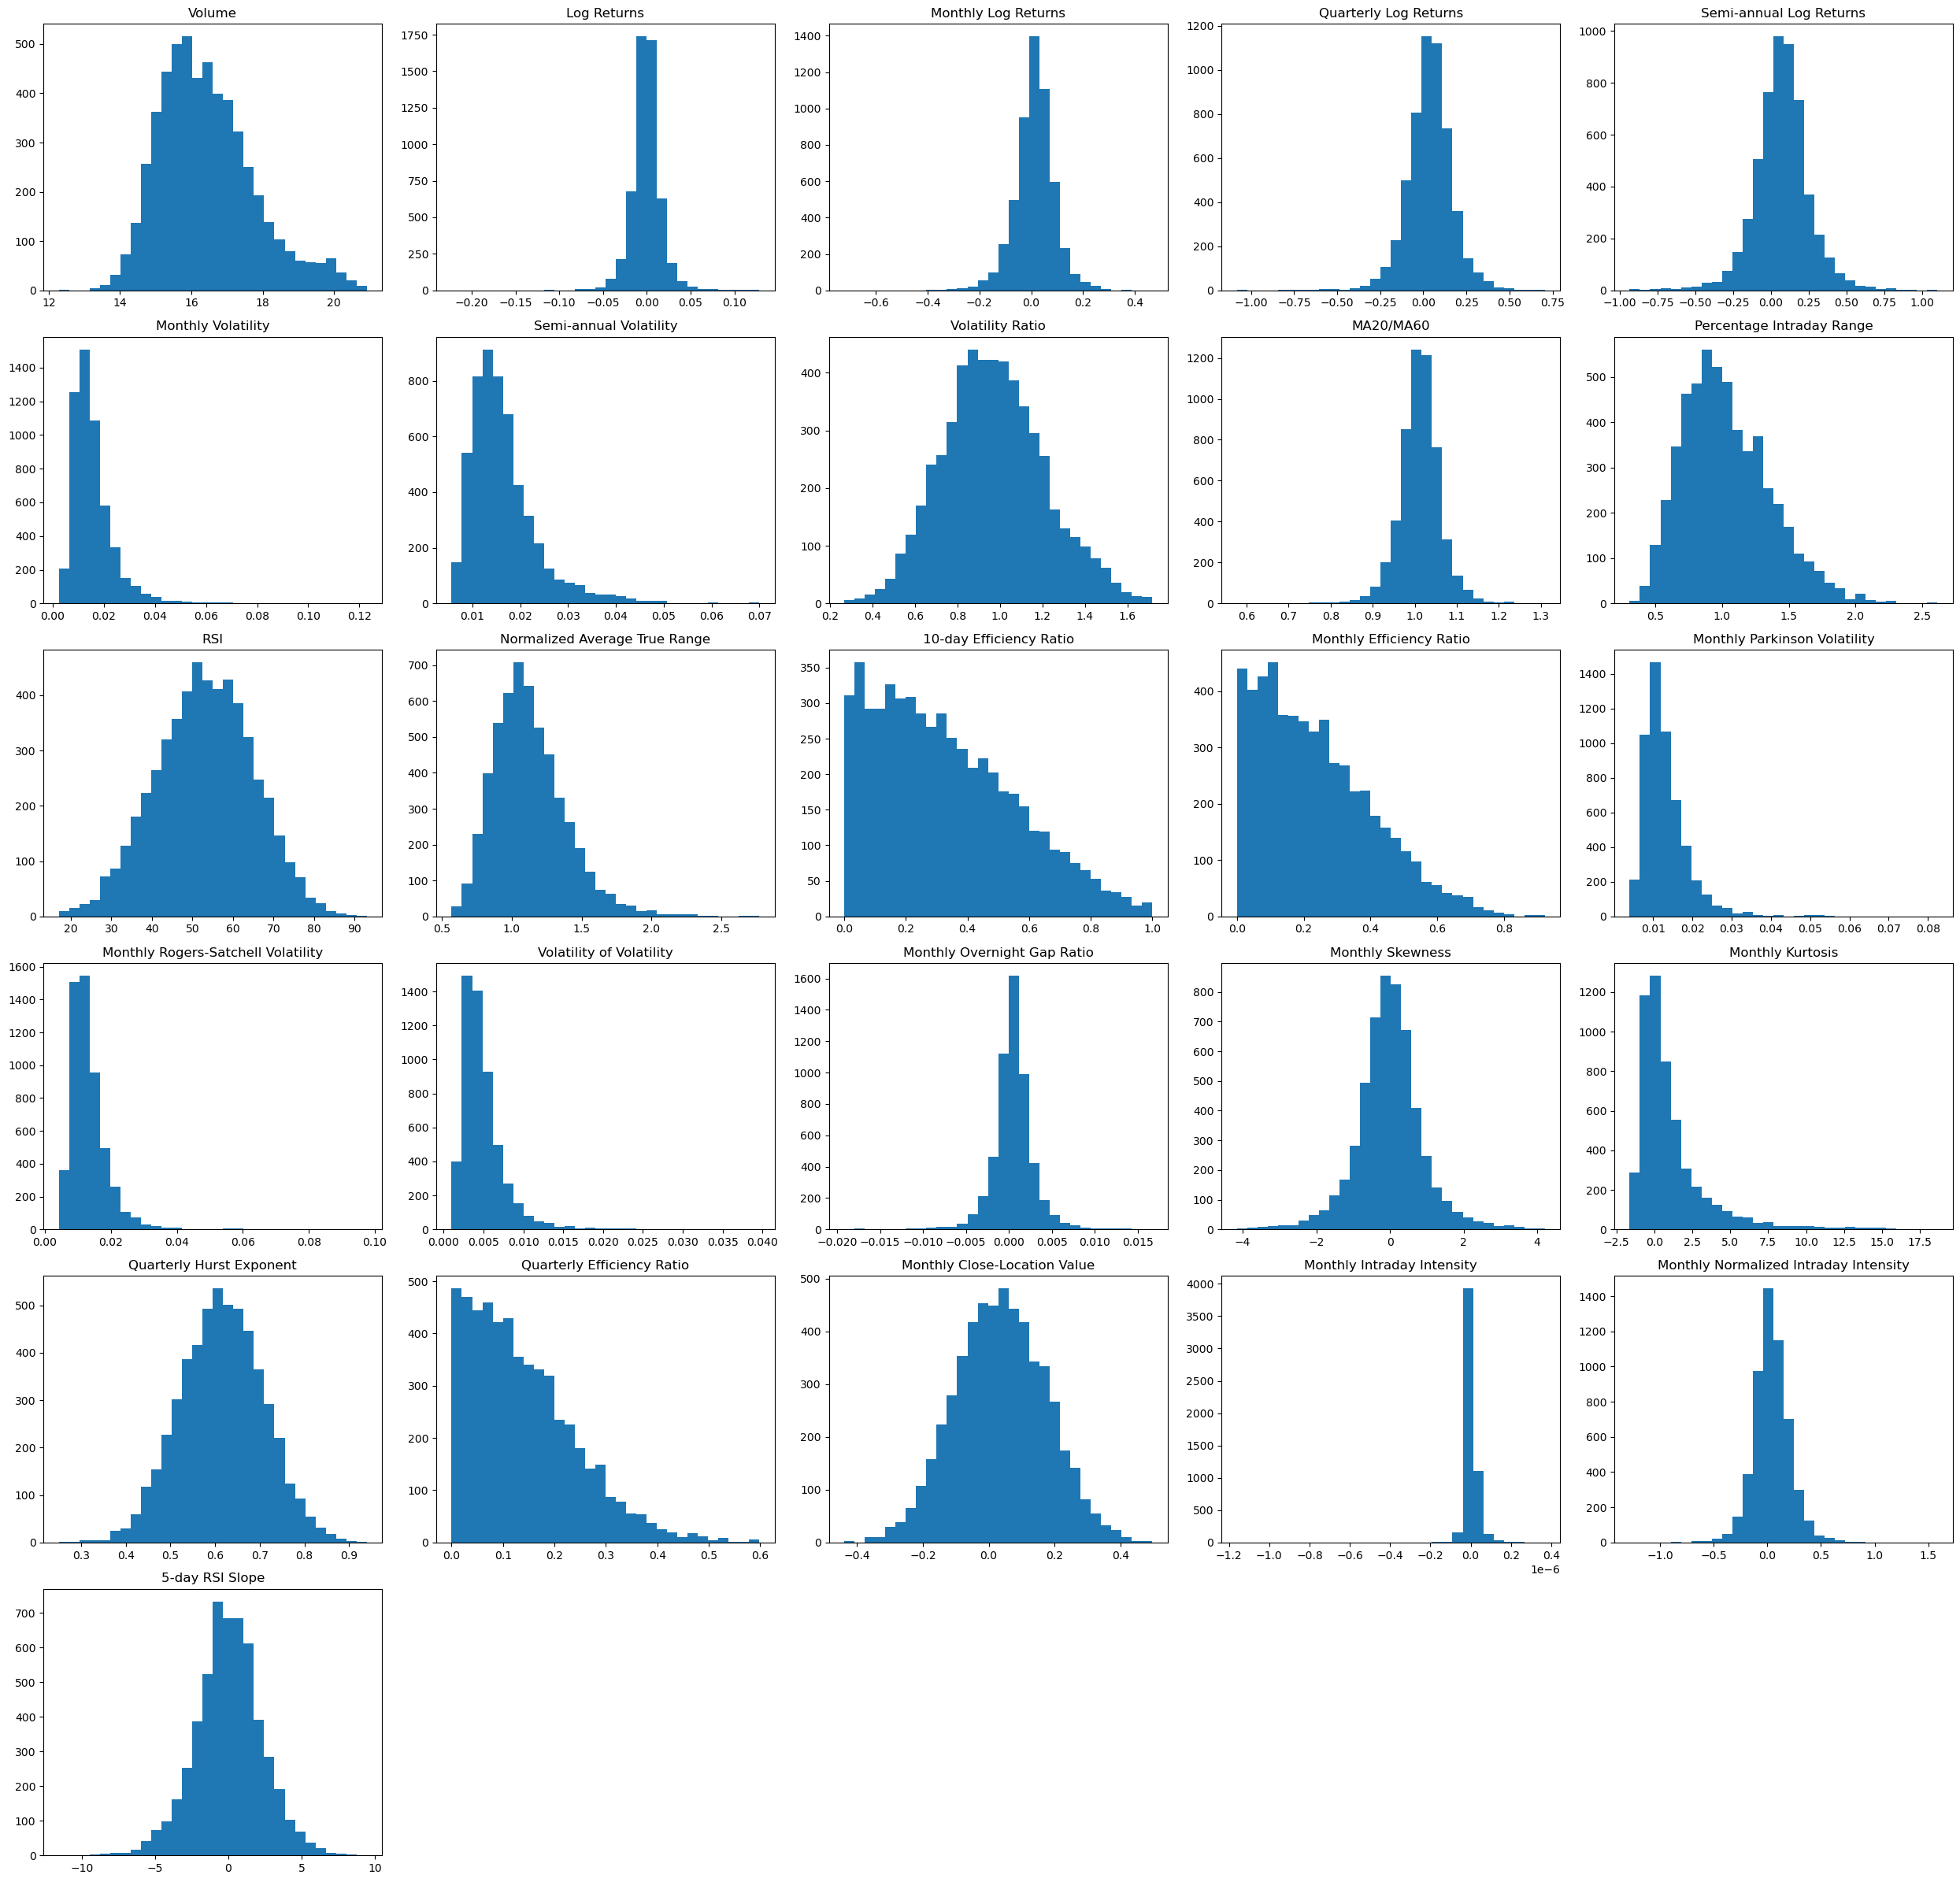

In [98]:
# move onto EDA and statistical testing, first univariate, then bivariate
# univariate

cols = [c for c in df.columns if c != "Target"]
n_cols = 5
n_rows = math.ceil(len(cols)/n_cols)

fig, axes = plt.subplots(n_rows,n_cols,figsize=(5*n_cols,4*n_rows))
axes = axes.flatten()

for i,col in enumerate(cols):
    axes[i].hist(df[col],bins=30)
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

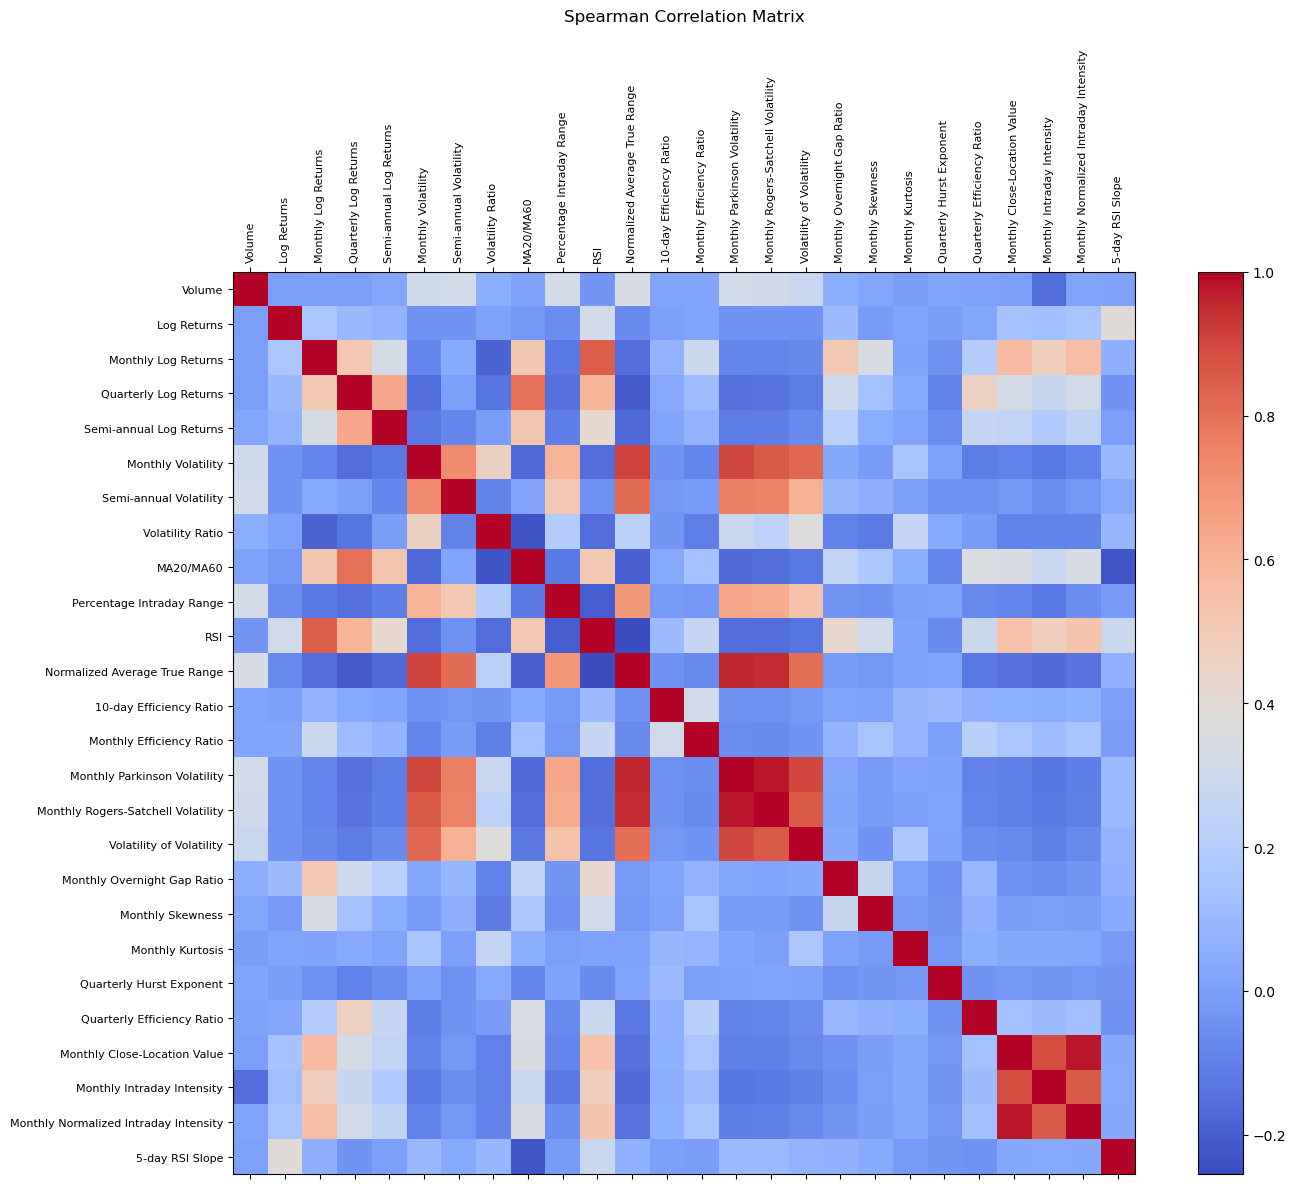

In [99]:
# will skip bivariate plots, straight into correlation matrix plot

corr_matrix = df.drop(columns=['Target']).corr(method='spearman')
fig, ax = plt.subplots(figsize=(15, 12))
cax = ax.matshow(corr_matrix, cmap='coolwarm')
fig.colorbar(cax)
ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=90, fontsize=8)
ax.set_yticklabels(corr_matrix.columns, fontsize=8)

plt.title("Spearman Correlation Matrix", pad=20)
plt.tight_layout()
plt.show()

In [100]:
# very clearly much less correlation between new set of features, good sign
# use same 0.9 threshold

high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > 0.9:  # check for strong correlation
            pair = (corr_matrix.columns[i], corr_matrix.columns[j], corr_value)
            high_corr_pairs.append(pair)

high_corr_pairs = sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True)

for pair in high_corr_pairs:
    print(f"{pair[0]} - {pair[1]}: {pair[2]:.2f}")

Monthly Parkinson Volatility - Monthly Rogers-Satchell Volatility: 0.98
Monthly Close-Location Value - Monthly Normalized Intraday Intensity: 0.98
Normalized Average True Range - Monthly Parkinson Volatility: 0.96
Normalized Average True Range - Monthly Rogers-Satchell Volatility: 0.95
Monthly Volatility - Normalized Average True Range: 0.91
Monthly Volatility - Monthly Parkinson Volatility: 0.90


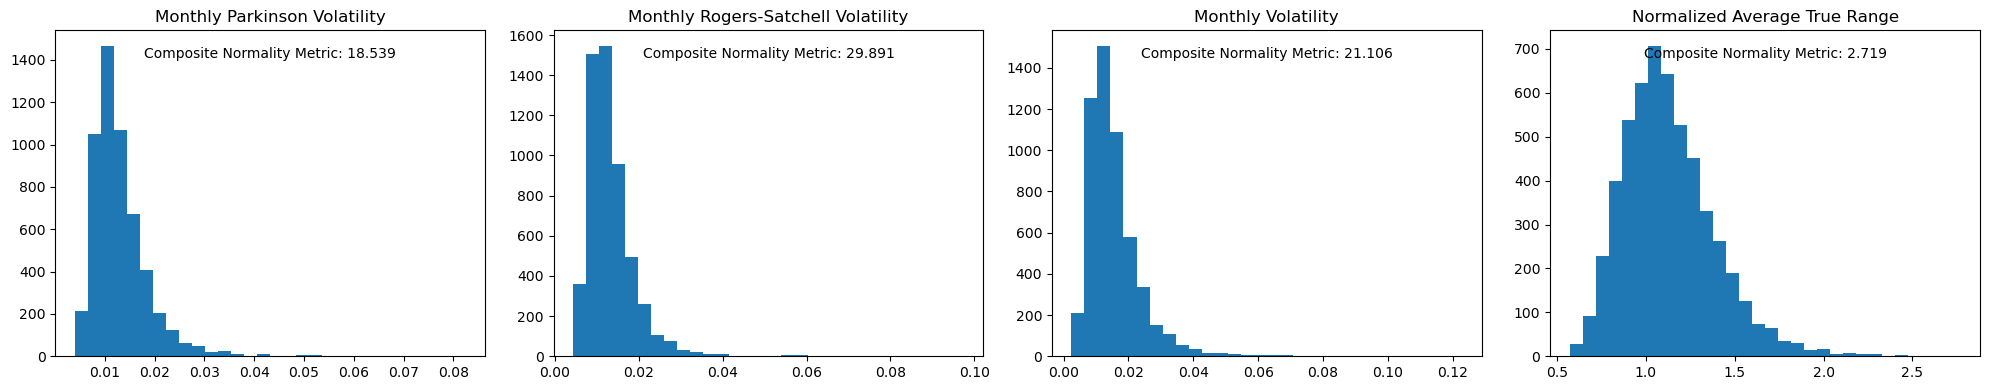

In [101]:
# Monthly Parkinson Volatility - Monthly Rogers-Satchell Volatility: 0.98
# Normalized Average True Range - Monthly Parkinson Volatility: 0.96
# Normalized Average True Range - Monthly Rogers-Satchell Volatility: 0.95
# Monthly Volatility - Normalized Average True Range: 0.91
# Monthly Volatility - Monthly Parkinson Volatility: 0.90

cols = [
 'Monthly Parkinson Volatility',
 'Monthly Rogers-Satchell Volatility',
 'Monthly Volatility',
 'Normalized Average True Range'
]

n_cols = 4
fig, axes = plt.subplots(1,n_cols,figsize=(5*n_cols,4))
axes = axes.flatten()

for i,col in enumerate(cols):
    axes[i].hist(df[col],bins=30)
    axes[i].set_title(col)
    score = abs(df[col].skew()) + abs(df[col].kurt())
    axes[i].text(0.5, 0.95, f'Composite Normality Metric: {score:.3f}',
             transform=axes[i].transAxes,
             ha='center', va='top')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [102]:
# monthly volatility is removed
# between monthly parkinson and monthly rogers satchell, the latter stays as it handles the non zero mean drift of stocks
# normalized ATR stays

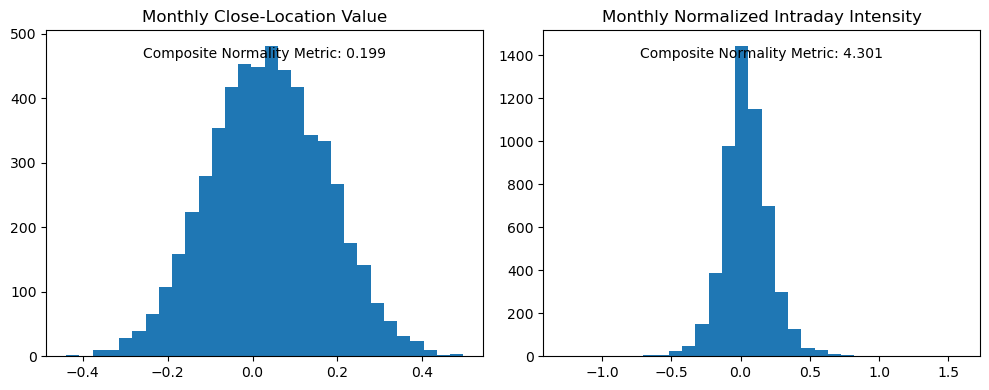

In [103]:
# Monthly Close-Location Value - Monthly Normalized Intraday Intensity: 0.98

cols = ["Monthly Close-Location Value", "Monthly Normalized Intraday Intensity" ]

n_cols = 2
fig, axes = plt.subplots(1,n_cols,figsize=(5*n_cols,4))
axes = axes.flatten()

for i,col in enumerate(cols):
    axes[i].hist(df[col],bins=30)
    axes[i].set_title(col)
    score = abs(df[col].skew()) + abs(df[col].kurt())
    axes[i].text(0.5, 0.95, f'Composite Normality Metric: {score:.3f}',
             transform=axes[i].transAxes,
             ha='center', va='top')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



In [104]:
# very clearly monthly close location value stays, very clearly more normal

In [105]:
# final list to remove after 2nd set of correlation tests:

features = [
    "Monthly Volatility",
    "Monthly Parkinson Volatility",
    "Monthly Normalized Intraday Intensity"
]

df = df.drop(columns=features)
df

,Volume,Log Returns,Monthly Log Returns,Quarterly Log Returns,Semi-annual Log Returns,Semi-annual Volatility,Volatility Ratio,MA20/MA60,Percentage Intraday Range,RSI,...,Volatility of Volatility,Monthly Overnight Gap Ratio,Monthly Skewness,Monthly Kurtosis,Quarterly Hurst Exponent,Quarterly Efficiency Ratio,Monthly Close-Location Value,Monthly Intraday Intensity,5-day RSI Slope,Target
0,16.590490,0.000000,0.152737,-0.111184,0.011336,0.022611,0.806682,0.985594,1.286407,63.398164,...,0.005602,0.004623,1.023518,1.888784,0.454704,0.099001,0.131642,8.207965e-09,0.046962,0.010587
1,16.431643,0.010587,-0.114312,-0.094229,-0.133644,0.022024,0.677686,1.019081,1.205079,37.321298,...,0.003252,-0.003712,-0.006665,0.109946,0.516303,0.103686,-0.075768,-5.537517e-09,0.332900,0.008137
2,16.881920,0.008137,-0.000405,0.068447,-0.164650,0.023095,1.137834,0.999165,1.278750,40.295403,...,0.005142,0.002577,-0.087914,-0.443236,0.598389,0.068812,0.000166,7.723982e-12,-0.690753,0.000402
3,16.710660,0.000402,0.009738,-0.104979,-0.197844,0.021740,0.892082,0.978417,0.877575,47.477383,...,0.006503,0.000366,0.241914,-0.019100,0.616572,0.122265,-0.103202,-5.706140e-09,2.594103,-0.018632
4,16.281600,-0.018632,-0.016624,-0.007290,-0.101520,0.019406,1.069011,1.005133,0.966728,41.916430,...,0.004957,-0.001744,0.375796,-0.935890,0.648690,0.006913,-0.091619,-7.779916e-09,-0.183492,-0.004401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5401,15.989330,0.016786,0.070288,-0.104563,-0.397550,0.035920,0.823890,0.880420,1.301824,53.985796,...,0.009426,0.003091,-0.246809,0.518557,0.694619,0.065408,-0.087192,-9.917442e-09,-0.033495,0.001746
5402,16.480563,0.001746,-0.071519,-0.179321,-0.381652,0.035820,0.608122,0.971031,1.340944,43.446508,...,0.007675,0.000152,0.572475,0.452187,0.572492,0.121510,-0.132509,-9.222065e-09,0.849135,0.002099
5403,16.384506,0.002099,0.006731,0.113902,-0.204354,0.032048,1.285608,0.982339,1.114648,53.118411,...,0.009505,0.004972,1.474990,4.955457,0.727716,0.085342,-0.105918,-8.114634e-09,-4.222704,0.012234
5404,15.797050,0.012234,-0.026729,-0.017435,-0.121997,0.032597,0.959965,0.978368,1.033915,60.322448,...,0.006638,0.000649,0.109623,-0.016206,0.698770,0.014024,-0.087570,-1.207212e-08,3.439285,-0.005545


In [106]:
# now 23 features, move onto VIF test, same as before

cols = [c for c in df.columns if c != "Target"]
X = df[cols].copy()
X["Intercept"] = 1
vif_data = pd.DataFrame()
vif_data["Feature"] = cols
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(cols))]
vif_data.sort_values("VIF", ascending=False)

,Feature,VIF
13,Monthly Rogers-Satchell Volatility,12.727739
10,Normalized Average True Range,12.405455
14,Volatility of Volatility,5.659753
9,RSI,5.131204
3,Quarterly Log Returns,5.020001
2,Monthly Log Returns,4.895423
5,Semi-annual Volatility,4.431603
7,MA20/MA60,4.288187
20,Monthly Close-Location Value,2.804394
8,Percentage Intraday Range,2.126509


In [107]:
# satchell volatility + monthly overnight gap ratio covers the overnight risk that normalized ATR does,
# satchell volatility can provide more signal, so we remove normalized ATR

df = df.drop(columns=["Normalized Average True Range"])

cols = [c for c in df.columns if c != "Target"]
X = df[cols].copy()
X["Intercept"] = 1
vif_data = pd.DataFrame()
vif_data["Feature"] = cols
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(cols))]
vif_data.sort_values("VIF", ascending=False)

,Feature,VIF
12,Monthly Rogers-Satchell Volatility,8.351477
13,Volatility of Volatility,5.550367
3,Quarterly Log Returns,4.907555
2,Monthly Log Returns,4.887972
9,RSI,4.797381
7,MA20/MA60,4.229505
5,Semi-annual Volatility,3.010632
19,Monthly Close-Location Value,2.802480
14,Monthly Overnight Gap Ratio,2.096413
4,Semi-annual Log Returns,2.073116


In [108]:
len(df.columns)

23

In [109]:
#22 features, move onto final MI test, same as before


X = df.drop(columns=["Target"])
y = df["Target"]
mi_scores = mutual_info_regression(X, y, discrete_features=False, random_state=42)
mi_results = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
print("--- Mutual Information Ranking ---")
print(mi_results)

--- Mutual Information Ranking ---
Monthly Rogers-Satchell Volatility    0.049226
Semi-annual Volatility                0.037578
Semi-annual Log Returns               0.025162
Volatility of Volatility              0.023241
Percentage Intraday Range             0.022602
Volatility Ratio                      0.020870
Monthly Intraday Intensity            0.018113
Volume                                0.017175
Monthly Efficiency Ratio              0.012235
Quarterly Efficiency Ratio            0.011723
MA20/MA60                             0.011023
Quarterly Log Returns                 0.009564
Log Returns                           0.008538
Monthly Kurtosis                      0.008349
10-day Efficiency Ratio               0.004585
RSI                                   0.003688
Monthly Skewness                      0.002488
Monthly Log Returns                   0.001800
Quarterly Hurst Exponent              0.000000
Monthly Overnight Gap Ratio           0.000000
Monthly Close-Location Va

In [110]:
# increased total MI by 0.026, about a 10% increase
# same as last time, features with 0 MI are removed

features = [
    "Quarterly Hurst Exponent",
    "Monthly Overnight Gap Ratio",
    "Monthly Close-Location Value",
    "5-day RSI Slope"
]

df = df.drop(columns=features)
print(len(df.columns))
df.columns



19


Index(['Volume', 'Log Returns', 'Monthly Log Returns', 'Quarterly Log Returns',
       'Semi-annual Log Returns', 'Semi-annual Volatility', 'Volatility Ratio',
       'MA20/MA60', 'Percentage Intraday Range', 'RSI',
       '10-day Efficiency Ratio', 'Monthly Efficiency Ratio',
       'Monthly Rogers-Satchell Volatility', 'Volatility of Volatility',
       'Monthly Skewness', 'Monthly Kurtosis', 'Quarterly Efficiency Ratio',
       'Monthly Intraday Intensity', 'Target'],
      dtype='str')

In [111]:
# 18 features now
# will try one last thing, instead of quarterly hurst, use monthly hurst to align better with target
# hurst exponent measures if its random walk or real trend, can be useful for market regime detection
# will add to process function, then reload data and redo steps in feature extraction one last time


# new monthly hurst exponent added
dfs = dl.load_multiple_data("processed")



MS.csv loaded succesfully
MMM.csv loaded succesfully
GS.csv loaded succesfully
CAT.csv loaded succesfully
AVGO.csv loaded succesfully
BA.csv loaded succesfully
MCD.csv loaded succesfully
HD.csv loaded succesfully
UNH.csv loaded succesfully
AMZN.csv loaded succesfully
META.csv loaded succesfully
AAPL.csv loaded succesfully
SLB.csv loaded succesfully
JPM.csv loaded succesfully
VZ.csv loaded succesfully
GOOG.csv loaded succesfully
CVX.csv loaded succesfully
NEE.csv loaded succesfully
BAC.csv loaded succesfully
UPS.csv loaded succesfully
MSFT.csv loaded succesfully
LIN.csv loaded succesfully
CMCSA.csv loaded succesfully
XOM.csv loaded succesfully
NKE.csv loaded succesfully
NVDA.csv loaded succesfully
JNJ.csv loaded succesfully
ABBV.csv loaded succesfully
PFE.csv loaded succesfully
DOW.csv loaded succesfully


In [112]:
for df in dfs.values():
    df.dropna(how='any', inplace=True)
for k,v in dfs.items():
    dfs[k] = v.resample("BME").last()
for k,v in dfs.items():
    v["Target"] = v["Log Returns"].shift(-1)
for df in dfs.values():
    df.dropna(subset=["Target"], inplace=True)
df = pd.concat(dfs.values(),axis=0).reset_index(drop=True)

# domain purge

domain_purge_list = ['Close', 'High', 
                    'Low', 'Open','MA20', 'MA60',
                    'True Range', 'Daily Range', 
                    'Daily Candle Body', 'Price Difference',
                    'Gains', 'Losses','Average Gains', 
                    'Average Losses','RS']
df = df.drop(columns=domain_purge_list)

# correlation test removal

features = [
    "Returns",
    "Monthly Average Intraday Range",
    "Monthly Average True Range",
    "Monthly Average Candle Body",
    "Monthly Average Percentage Intraday Range",
    "VMA60",
    "Parkinson Volatility",
    "Quarterly Volatility",
    "Distance from MA20"
]

df = df.drop(columns=features)

# VIF removal

df = df.drop(columns=["VMA20"])
df = df.drop(columns=["Distance from MA60"])

# MI removal

features = [
    "Volume Flow Ratio",
    "Relative Volume",
    "14-day Average True Range",
    "Body Up",
    "Body Down",
    "Monthly Conviction Ratio"
]

df = df.drop(columns=features)


# final list to remove after 2nd set of correlation tests:

features = [
    "Monthly Volatility",
    "Monthly Parkinson Volatility",
    "Monthly Normalized Intraday Intensity"
]

df = df.drop(columns=features)

# 2nd VIF test

df = df.drop(columns=["Normalized Average True Range"])

# 2nd MI test

features = [
    "Quarterly Hurst Exponent",
    "Monthly Overnight Gap Ratio",
    "Monthly Close-Location Value",
    "5-day RSI Slope"
]

df = df.drop(columns=features)


print(df.columns)
print(len(df.columns)-1)


Index(['Volume', 'Log Returns', 'Monthly Log Returns', 'Quarterly Log Returns',
       'Semi-annual Log Returns', 'Semi-annual Volatility', 'Volatility Ratio',
       'MA20/MA60', 'Percentage Intraday Range', 'RSI',
       '10-day Efficiency Ratio', 'Monthly Efficiency Ratio',
       'Monthly Rogers-Satchell Volatility', 'Volatility of Volatility',
       'Monthly Skewness', 'Monthly Kurtosis', 'Monthly Hurst Exponent',
       'Quarterly Efficiency Ratio', 'Monthly Intraday Intensity', 'Target'],
      dtype='str')
19


In [113]:
skewed = df.skew() >= 1
non_negative = (df >= 0).all()

features = df.columns[skewed & non_negative].tolist()
features

['Volume',
 'Semi-annual Volatility',
 'Percentage Intraday Range',
 'Monthly Rogers-Satchell Volatility',
 'Volatility of Volatility']

In [114]:
df[features] = np.log1p(df[features])
df

,Volume,Log Returns,Monthly Log Returns,Quarterly Log Returns,Semi-annual Log Returns,Semi-annual Volatility,Volatility Ratio,MA20/MA60,Percentage Intraday Range,RSI,10-day Efficiency Ratio,Monthly Efficiency Ratio,Monthly Rogers-Satchell Volatility,Volatility of Volatility,Monthly Skewness,Monthly Kurtosis,Monthly Hurst Exponent,Quarterly Efficiency Ratio,Monthly Intraday Intensity,Target
0,16.590490,0.000000,0.152737,-0.111184,0.011336,0.022611,0.806682,0.985594,1.286407,63.398164,0.974548,0.557497,0.019857,0.005602,1.023518,1.888784,0.612272,0.099001,8.207965e-09,0.010587
1,16.431643,0.010587,-0.114312,-0.094229,-0.133644,0.022024,0.677686,1.019081,1.205079,37.321298,0.511865,0.483036,0.014206,0.003252,-0.006665,0.109946,1.012982,0.103686,-5.537517e-09,0.008137
2,16.881920,0.008137,-0.000405,0.068447,-0.164650,0.023095,1.137834,0.999165,1.278750,40.295403,0.517241,0.000989,0.014718,0.005142,-0.087914,-0.443236,0.385095,0.068812,7.723982e-12,0.000402
3,16.710660,0.000402,0.009738,-0.104979,-0.197844,0.021740,0.892082,0.978417,0.877575,47.477383,0.042420,0.038572,0.018293,0.006503,0.241914,-0.019100,0.765420,0.122265,-5.706140e-09,-0.018632
4,16.281600,-0.018632,-0.016624,-0.007290,-0.101520,0.019406,1.069011,1.005133,0.966728,41.916430,0.383084,0.042933,0.015263,0.004957,0.375796,-0.935890,1.118267,0.006913,-7.779916e-09,-0.004401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5401,15.989330,0.016786,0.070288,-0.104563,-0.397550,0.035920,0.823890,0.880420,1.301824,53.985796,0.436381,0.156221,0.022047,0.009426,-0.246809,0.518557,0.530088,0.065408,-9.917442e-09,0.001746
5402,16.480563,0.001746,-0.071519,-0.179321,-0.381652,0.035820,0.608122,0.971031,1.340944,43.446508,0.406824,0.200000,0.023724,0.007675,0.572475,0.452187,0.643704,0.121510,-9.222065e-09,0.002099
5403,16.384506,0.002099,0.006731,0.113902,-0.204354,0.032048,1.285608,0.982339,1.114648,53.118411,0.304348,0.013559,0.020955,0.009505,1.474990,4.955457,0.911388,0.085342,-8.114634e-09,0.012234
5404,15.797050,0.012234,-0.026729,-0.017435,-0.121997,0.032597,0.959965,0.978368,1.033915,60.322448,0.189513,0.063021,0.018641,0.006638,0.109623,-0.016206,0.558728,0.014024,-1.207212e-08,-0.005545


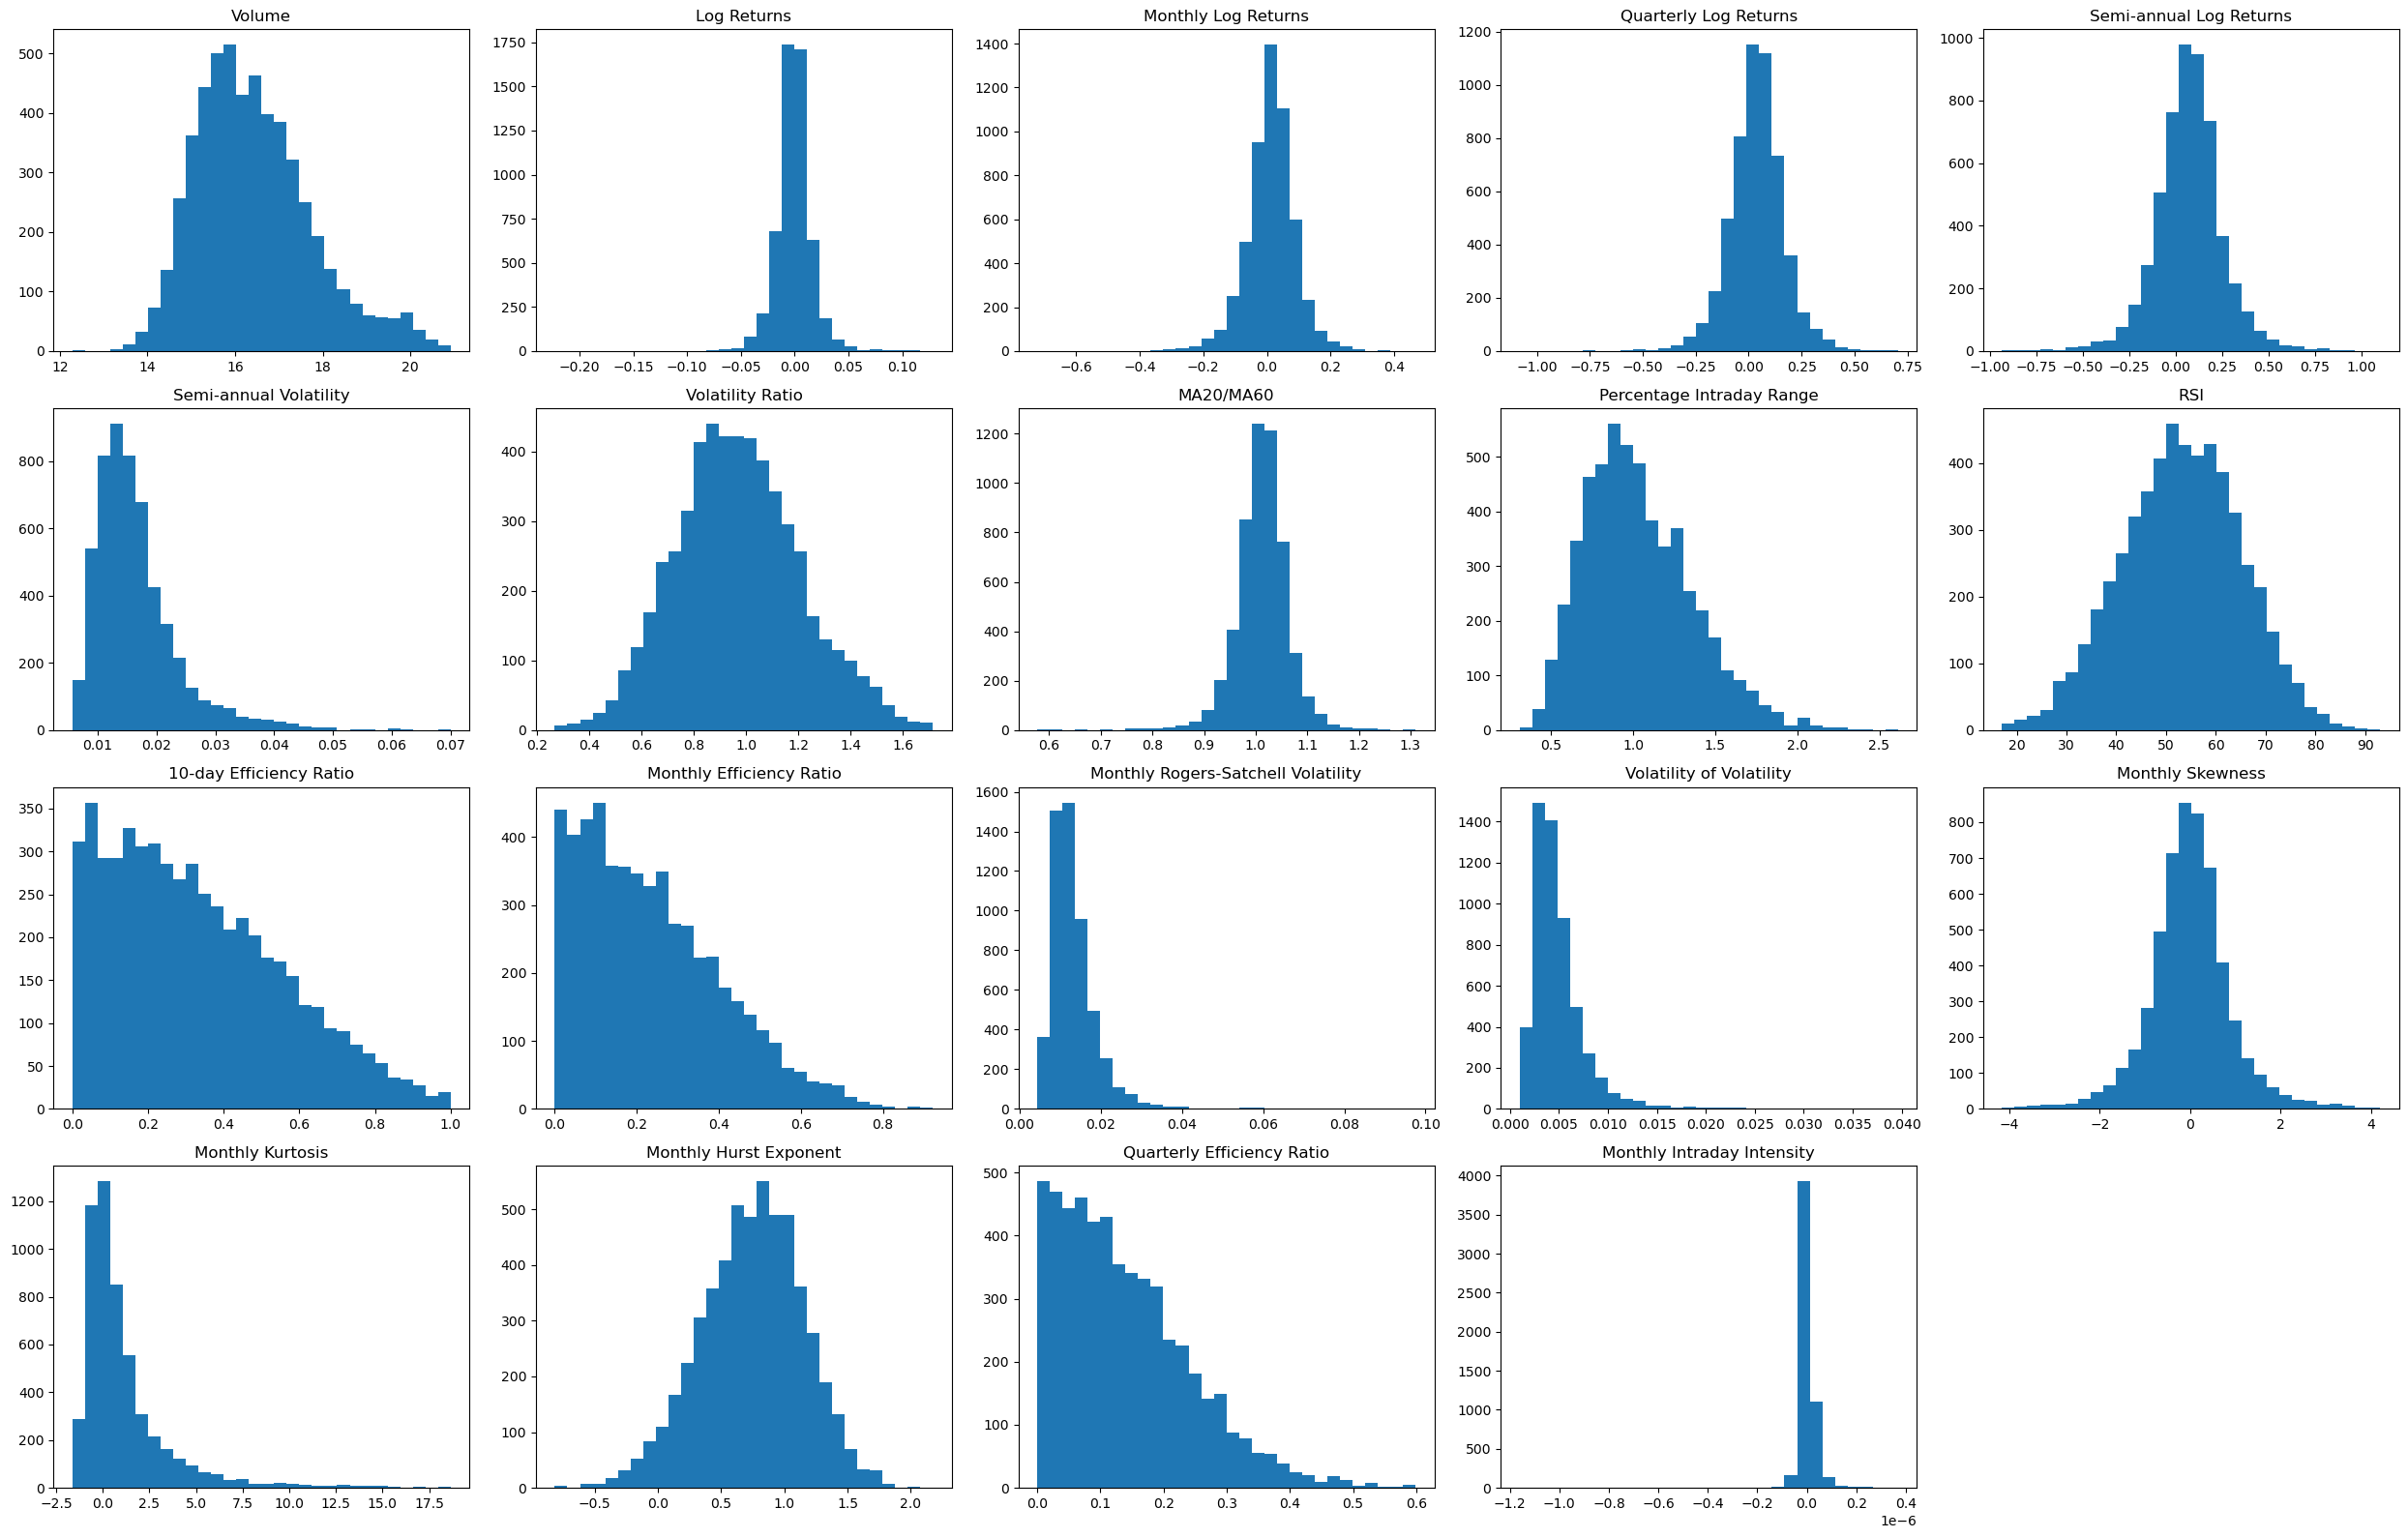

In [115]:
# move onto EDA and statistical testing, first univariate, then bivariate
# univariate

cols = [c for c in df.columns if c != "Target"]
n_cols = 5
n_rows = math.ceil(len(cols)/n_cols)

fig, axes = plt.subplots(n_rows,n_cols,figsize=(5*n_cols,4*n_rows))
axes = axes.flatten()

for i,col in enumerate(cols):
    axes[i].hist(df[col],bins=30)
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

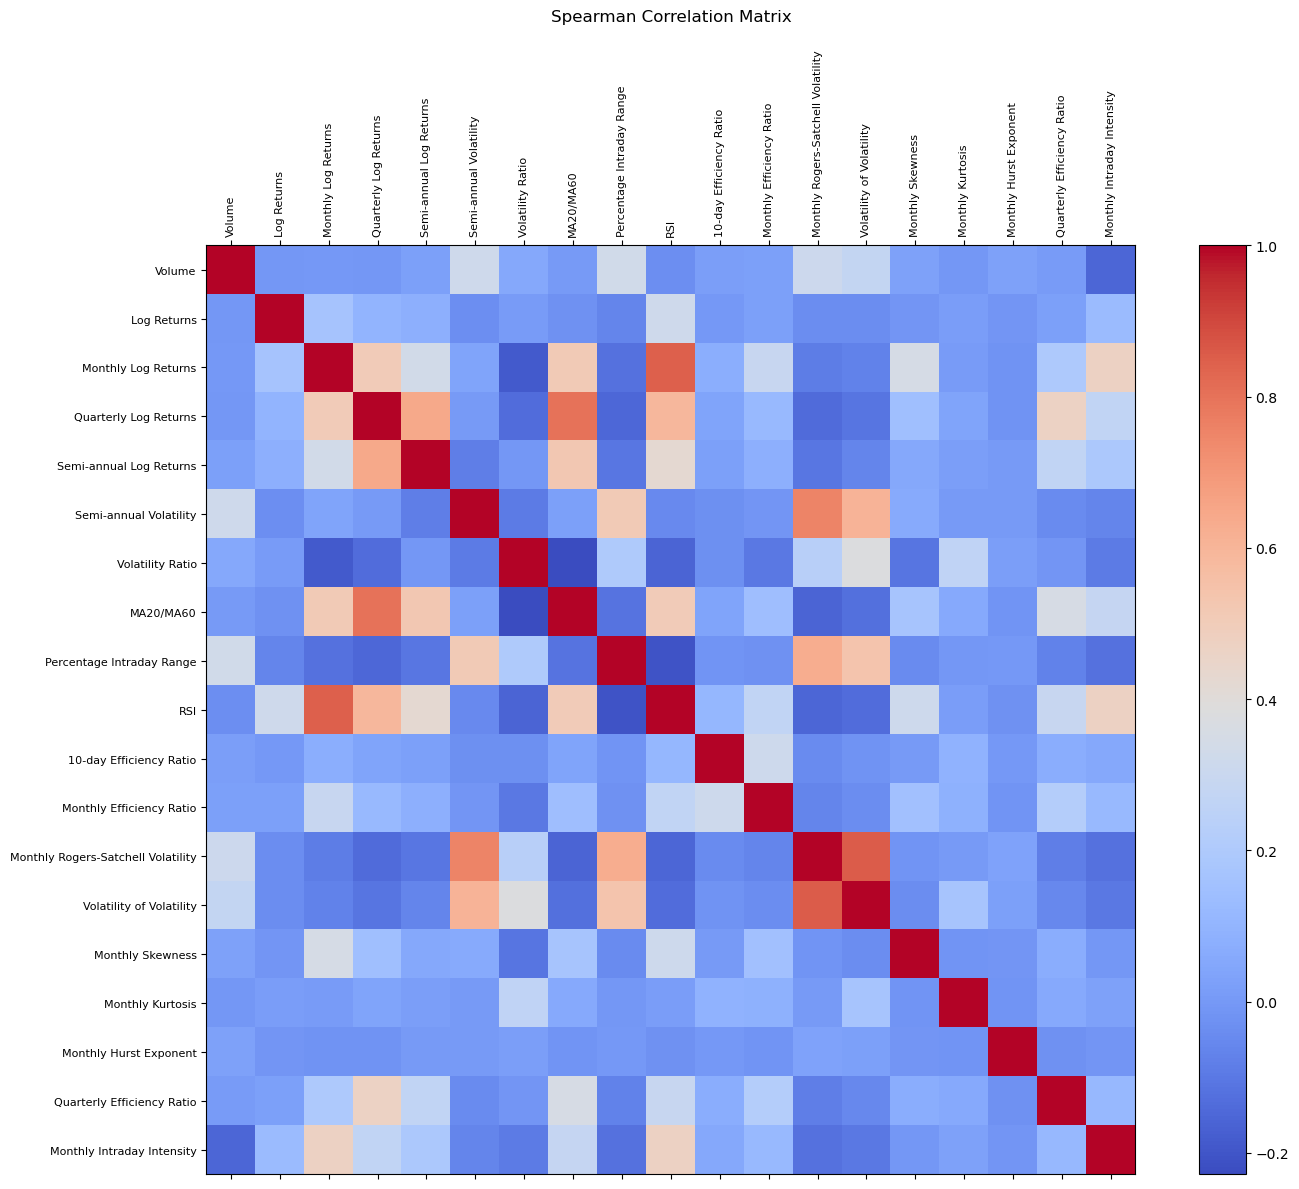

In [116]:
# will skip bivariate plots, straight into correlation matrix plot

corr_matrix = df.drop(columns=['Target']).corr(method='spearman')
fig, ax = plt.subplots(figsize=(15, 12))
cax = ax.matshow(corr_matrix, cmap='coolwarm')
fig.colorbar(cax)
ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=90, fontsize=8)
ax.set_yticklabels(corr_matrix.columns, fontsize=8)

plt.title("Spearman Correlation Matrix", pad=20)
plt.tight_layout()
plt.show()

In [117]:
# expect to see no correlations
# very clearly much less correlation between new set of features, good sign
# use same 0.9 threshold

high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > 0.9:  # check for strong correlation
            pair = (corr_matrix.columns[i], corr_matrix.columns[j], corr_value)
            high_corr_pairs.append(pair)

high_corr_pairs = sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True)

for pair in high_corr_pairs:
    print(f"{pair[0]} - {pair[1]}: {pair[2]:.2f}")

In [119]:
# as expected, move onto VIF

cols = [c for c in df.columns if c != "Target"]
X = df[cols].copy()
X["Intercept"] = 1
vif_data = pd.DataFrame()
vif_data["Feature"] = cols
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(cols))]
vif_data.sort_values("VIF", ascending=False)


,Feature,VIF
12,Monthly Rogers-Satchell Volatility,8.240219
13,Volatility of Volatility,5.534089
3,Quarterly Log Returns,4.880684
7,MA20/MA60,3.976381
9,RSI,3.874176
2,Monthly Log Returns,3.382621
5,Semi-annual Volatility,2.927274
4,Semi-annual Log Returns,2.057288
6,Volatility Ratio,1.827052
8,Percentage Intraday Range,1.780624


In [120]:
# as expected no need to remove any features,
# finally, see if monthly hurst has any relevance to target

X = df.drop(columns=["Target"])
y = df["Target"]
mi_scores = mutual_info_regression(X, y, discrete_features=False, random_state=42)
mi_results = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
print("--- Mutual Information Ranking ---")
print(mi_results)

--- Mutual Information Ranking ---
Monthly Rogers-Satchell Volatility    0.049211
Semi-annual Volatility                0.037551
Semi-annual Log Returns               0.025199
Volatility of Volatility              0.023236
Percentage Intraday Range             0.022569
Volatility Ratio                      0.020895
Monthly Intraday Intensity            0.018166
Volume                                0.017182
Monthly Efficiency Ratio              0.012230
Quarterly Efficiency Ratio            0.011688
MA20/MA60                             0.011034
Quarterly Log Returns                 0.009536
Log Returns                           0.008398
Monthly Kurtosis                      0.008365
10-day Efficiency Ratio               0.004578
RSI                                   0.003724
Monthly Skewness                      0.002514
Monthly Log Returns                   0.001805
Monthly Hurst Exponent                0.000000
dtype: float64


In [122]:
# it doesn't so we stay with the final 18 features we had
df = df.drop(columns=["Monthly Hurst Exponent"])
print(df.columns)
print(len(df.columns)-1)

Index(['Volume', 'Log Returns', 'Monthly Log Returns', 'Quarterly Log Returns',
       'Semi-annual Log Returns', 'Semi-annual Volatility', 'Volatility Ratio',
       'MA20/MA60', 'Percentage Intraday Range', 'RSI',
       '10-day Efficiency Ratio', 'Monthly Efficiency Ratio',
       'Monthly Rogers-Satchell Volatility', 'Volatility of Volatility',
       'Monthly Skewness', 'Monthly Kurtosis', 'Quarterly Efficiency Ratio',
       'Monthly Intraday Intensity', 'Target'],
      dtype='str')
18


In [123]:
# we have our final dataset
df

,Volume,Log Returns,Monthly Log Returns,Quarterly Log Returns,Semi-annual Log Returns,Semi-annual Volatility,Volatility Ratio,MA20/MA60,Percentage Intraday Range,RSI,10-day Efficiency Ratio,Monthly Efficiency Ratio,Monthly Rogers-Satchell Volatility,Volatility of Volatility,Monthly Skewness,Monthly Kurtosis,Quarterly Efficiency Ratio,Monthly Intraday Intensity,Target
0,16.590490,0.000000,0.152737,-0.111184,0.011336,0.022611,0.806682,0.985594,1.286407,63.398164,0.974548,0.557497,0.019857,0.005602,1.023518,1.888784,0.099001,8.207965e-09,0.010587
1,16.431643,0.010587,-0.114312,-0.094229,-0.133644,0.022024,0.677686,1.019081,1.205079,37.321298,0.511865,0.483036,0.014206,0.003252,-0.006665,0.109946,0.103686,-5.537517e-09,0.008137
2,16.881920,0.008137,-0.000405,0.068447,-0.164650,0.023095,1.137834,0.999165,1.278750,40.295403,0.517241,0.000989,0.014718,0.005142,-0.087914,-0.443236,0.068812,7.723982e-12,0.000402
3,16.710660,0.000402,0.009738,-0.104979,-0.197844,0.021740,0.892082,0.978417,0.877575,47.477383,0.042420,0.038572,0.018293,0.006503,0.241914,-0.019100,0.122265,-5.706140e-09,-0.018632
4,16.281600,-0.018632,-0.016624,-0.007290,-0.101520,0.019406,1.069011,1.005133,0.966728,41.916430,0.383084,0.042933,0.015263,0.004957,0.375796,-0.935890,0.006913,-7.779916e-09,-0.004401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5401,15.989330,0.016786,0.070288,-0.104563,-0.397550,0.035920,0.823890,0.880420,1.301824,53.985796,0.436381,0.156221,0.022047,0.009426,-0.246809,0.518557,0.065408,-9.917442e-09,0.001746
5402,16.480563,0.001746,-0.071519,-0.179321,-0.381652,0.035820,0.608122,0.971031,1.340944,43.446508,0.406824,0.200000,0.023724,0.007675,0.572475,0.452187,0.121510,-9.222065e-09,0.002099
5403,16.384506,0.002099,0.006731,0.113902,-0.204354,0.032048,1.285608,0.982339,1.114648,53.118411,0.304348,0.013559,0.020955,0.009505,1.474990,4.955457,0.085342,-8.114634e-09,0.012234
5404,15.797050,0.012234,-0.026729,-0.017435,-0.121997,0.032597,0.959965,0.978368,1.033915,60.322448,0.189513,0.063021,0.018641,0.006638,0.109623,-0.016206,0.014024,-1.207212e-08,-0.005545


## Complete Summary of Feature Extraction Findings

### Process and Selection Logic

- Starting point: **46 engineered features** from the processed pipeline.
- Data preparation: warm-up NaNs removed, monthly resampling (`BME`) applied, and **Target** defined as next-month log return.
- Selection criteria were applied iteratively: domain purge, pairwise correlation filtering (threshold `|rho| > 0.9`), VIF review, and mutual information ranking.
- Additional candidate features were tested (volatility/distribution/market microstructure/Hurst), then re-evaluated through the same pipeline.

### Main Empirical Results

- High-correlation pairs were detected and removed in earlier rounds (e.g., Parkinson vs Rogers-Satchell volatility; close-location value vs normalized intraday intensity).
- Final multicollinearity check is acceptable (highest VIF observed around **8.24**, with most features much lower).
- Mutual information ranking is led by **Monthly Rogers-Satchell Volatility**, followed by semi-annual volatility and return/volatility features.
- **Monthly Hurst Exponent** showed zero MI in the final check and was removed.

### Final Dataset

The final selected dataset contains **18 predictive features** (+ target):

- Volume
- Log Returns
- Monthly Log Returns
- Quarterly Log Returns
- Semi-annual Log Returns
- Semi-annual Volatility
- Volatility Ratio
- MA20/MA60
- Percentage Intraday Range
- RSI
- 10-day Efficiency Ratio
- Monthly Efficiency Ratio
- Monthly Rogers-Satchell Volatility
- Volatility of Volatility
- Monthly Skewness
- Monthly Kurtosis
- Quarterly Efficiency Ratio
- Monthly Intraday Intensity

### Conclusion

The final feature space is substantially reduced from the original set while preserving the strongest predictive signals and limiting redundancy. This produces a cleaner and more robust input matrix for the next modeling and backtesting stages.